# Lattice model

Notebook to generate Figures 2 and S1

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


import os, sys
main_path = '../'

sys.path.append(main_path + 'PGM/source/')
sys.path.append(main_path + 'PGM/utilities/')
import utilities, Proteins_utils, sequence_logo, plots_utils, RBM_utils

sys.path.append(main_path + 'path/')
#importlib

from path import *

import lattice







# Parameters

In [71]:
RBM=RBM_utils.loadRBM('rbm/RBM_structure_0_beta_1000')



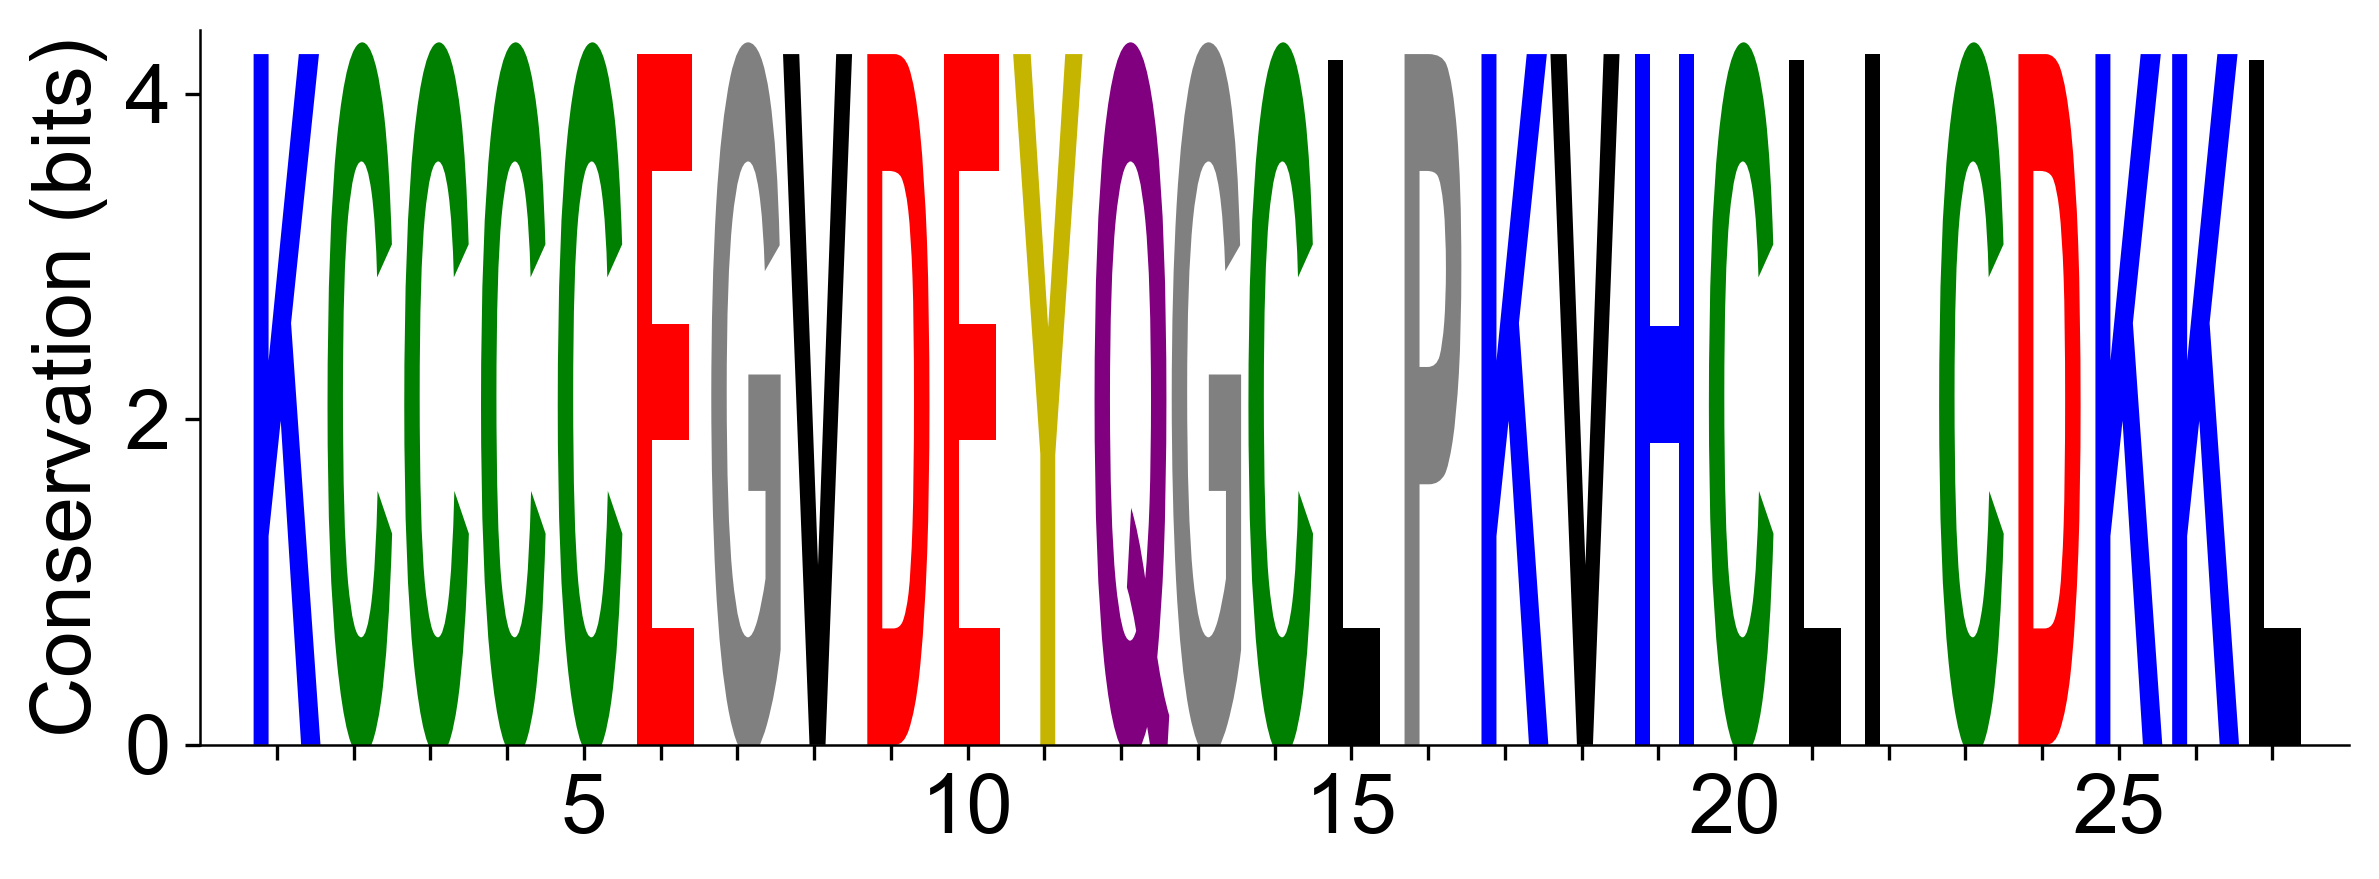

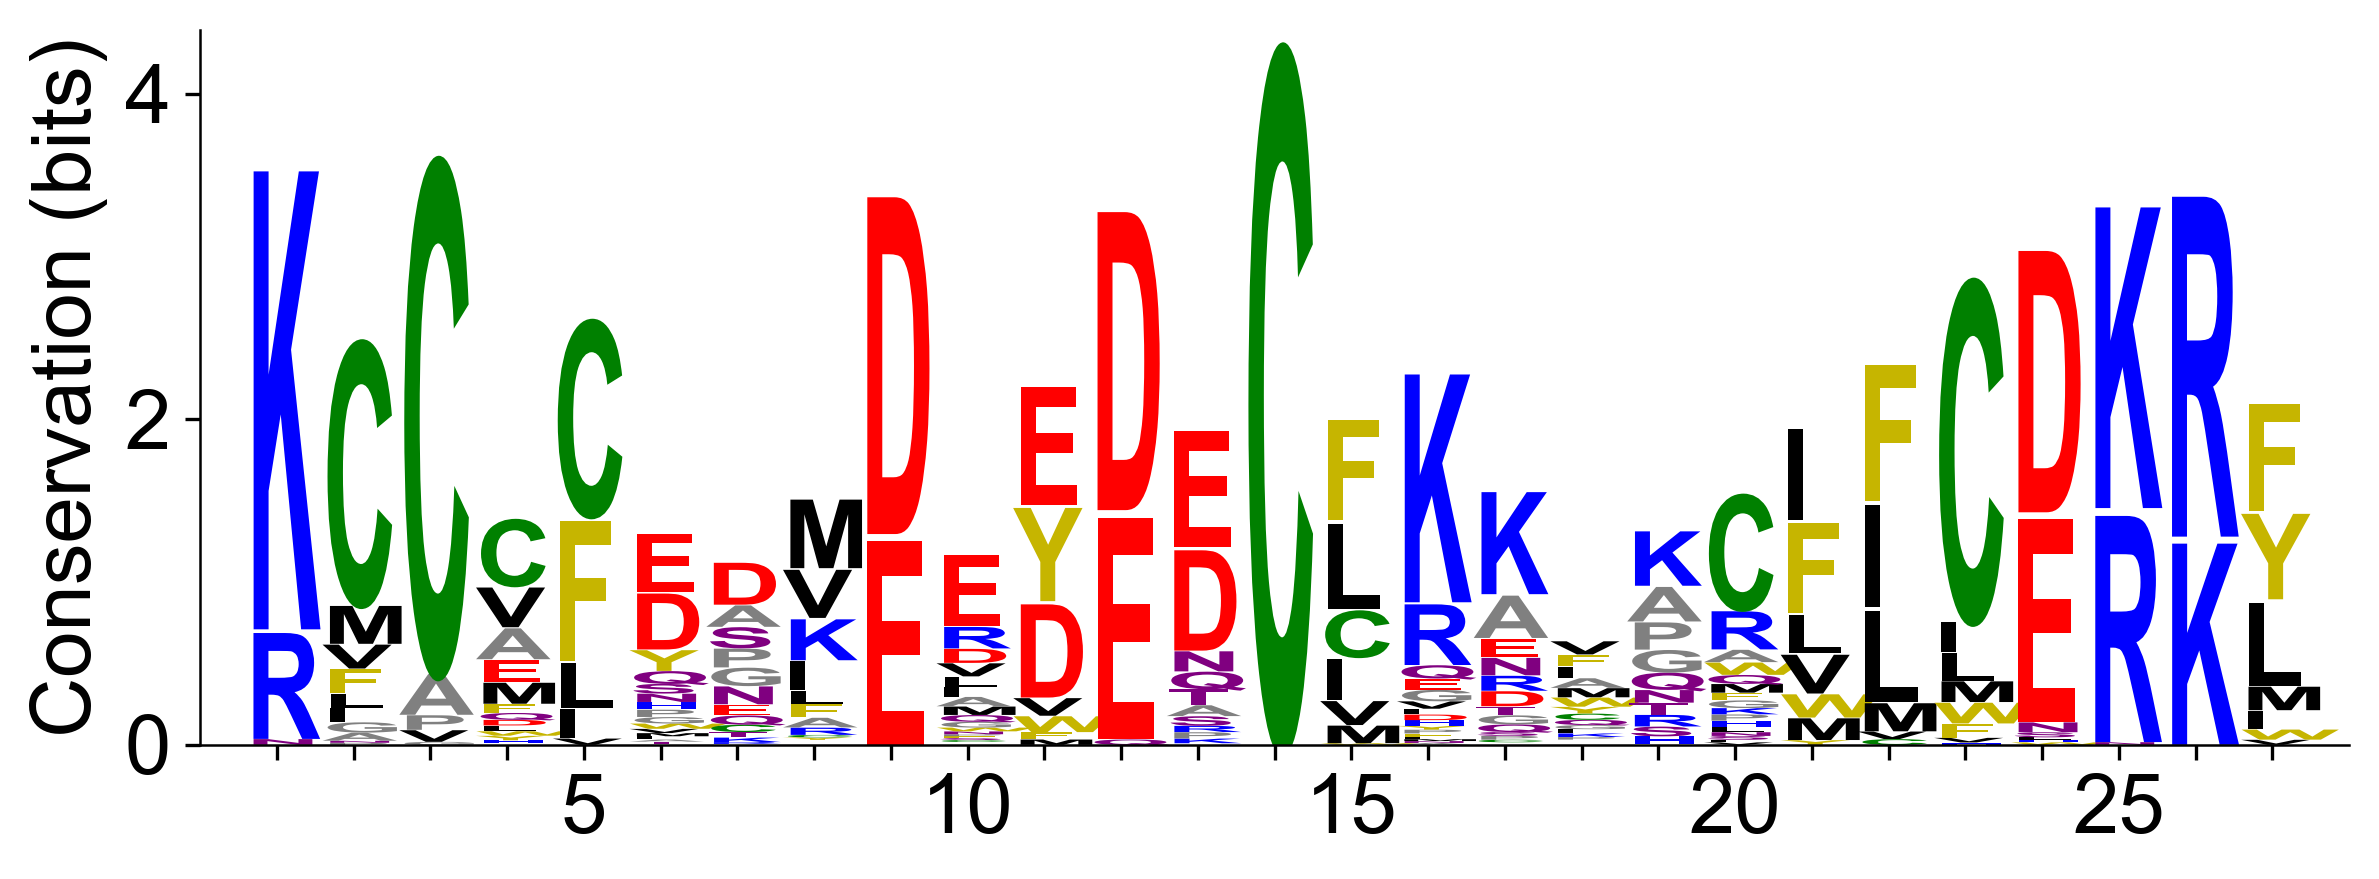

In [72]:
msa_seqs=Proteins_utils.load_FASTA('msa/output_msa_structure_0_beta_1000.fasta')
PROTEIN_INIT=Proteins_utils.load_FASTA('msa/output_msa_structure_0_beta_1000.fasta')[0] # Load the protein sequence from the FASTA file.
position_weight_init = utilities.average(np.array([PROTEIN_INIT]),c=20) # Compute Position Weight Matrix (i.e. frequency of each amino acid at each site)
position_weight_msa = utilities.average(msa_seqs,c=20) # Compute Position Weight Matrix (i.e. frequency of each amino acid at each site)

sequence_logo.Sequence_logo(position_weight_init, nrows=1, x_start=0,ticks_every=5,ticks_labels_size=20); # Visualize sequence logo of the MSA.
sequence_logo.Sequence_logo(position_weight_msa, nrows=1, x_start=0,ticks_every=5,ticks_labels_size=20); # Visualize sequence logo of the MSA.


In [73]:
def one_hot_encode_concat(s):
    # Number of categories for one-hot encoding, 21 for values 0 through 20
    num_categories = 20
    # Create a numpy array of zeros with shape [len(s), num_categories]
    one_hot_matrix = np.zeros((len(s), num_categories))

    # Use numpy indexing to set the appropriate elements to 1
    one_hot_matrix[np.arange(len(s)), s.astype(int)] = 1

    # Flatten the one-hot matrix to a 1D array
    one_hot_encoded = one_hot_matrix.flatten()

    return one_hot_encoded
one_hot_seq=one_hot_encode_concat(PROTEIN_INIT)


In [74]:

def P_fixation(v,v_prime):
    return 0

T=10

beta_pi=0
beta_rbm=1

class customed_RBM():
    def __init__(self,Rbm, w=None, beta_w=0, beta_rbm=1):
        self.Rbm=Rbm
        self.w=w
        self.beta_w=beta_w
        self.beta_rbm=beta_rbm
    def __call__(self,v):
        if self.w is None:
            return -self.Rbm.free_energy(v)[0]*self.beta_rbm
        else:
            return -self.Rbm.free_energy(v)[0]*self.beta_rbm + self.beta_w*np.dot(one_hot_encode_concat(v),self.w)

def get_E_contrib(customed_rbm, v):
    """return the energy contribution of the fields, w and total energy of the customed rbm"""
    #make sure customed rbm has a w
    assert customed_rbm.w is not None
    v_hot=one_hot_encode_concat(v)
    #rbm fields
    g = np.expand_dims(RBM.vlayer.fields[:, :], axis=-1).reshape(-1)
    
    fields_e=-np.dot(g.T,v_hot)
    w_e=-np.dot(v_hot,customed_rbm.w)*customed_rbm.beta_w
    gamma_e=customed_rbm.Rbm.free_energy(v)[0]-fields_e
    return fields_e, w_e, gamma_e

print("No w:")
customed_rbm=customed_RBM(RBM,w=None)
print('init seq lll',-RBM.free_energy(PROTEIN_INIT)[0])
print('init seq_lll_customed',customed_rbm(PROTEIN_INIT))

print("With w:")

random_w=np.random.normal(size=(PROTEIN_INIT.shape[0]*20))

customed_rbm_w=customed_RBM(RBM,w=random_w,beta_w=0.5)
print('init seq_lll_customed',customed_rbm_w(PROTEIN_INIT))

fields_e, w_e, gamma_e=get_E_contrib(customed_rbm_w, PROTEIN_INIT)
print('fields_e',fields_e)
print('w_e',w_e)
print('gamma_e',gamma_e)



No w:
init seq lll 264.47443
init seq_lll_customed 264.47442626953125
With w:
init seq_lll_customed 265.0233396737663
fields_e -248.02688813209534
w_e -0.5489134042350754
gamma_e -16.447538137435913


In [75]:
g = np.expand_dims(RBM.vlayer.fields[:, :], axis=-1).reshape(-1)
g

array([ -2.199057  ,  -2.199057  ,  -2.199057  ,  -2.199057  ,
        -2.199057  ,  -2.199057  ,  -2.199057  ,  -2.199057  ,
        14.497348  ,  -2.199057  ,  -2.199057  ,  10.062804  ,
        -2.199057  ,  -2.199057  ,  12.823816  ,  -2.199057  ,
        -2.199057  ,  -2.199057  ,  -2.199057  ,  -2.199057  ,
         6.2291794 ,   9.829397  ,  -6.7461834 ,  -6.7461834 ,
         7.269695  ,   6.2899237 ,  -6.7461834 ,   6.7234783 ,
        -6.7461834 ,   6.562935  ,   7.5940766 ,   4.877475  ,
         4.8987246 ,  -6.7461834 ,  -6.7461834 ,  -6.7461834 ,
        -6.7461834 ,   7.186953  ,  -6.7461834 ,  -6.7461834 ,
        10.453661  ,  13.504     ,  -3.420763  ,  -3.420763  ,
        -3.420763  ,   8.199242  ,  -3.420763  ,  -3.420763  ,
        -3.420763  ,  -3.420763  ,  -3.420763  ,  -3.420763  ,
         9.685697  ,  -3.420763  ,  -3.420763  ,  -3.420763  ,
        -3.420763  ,   9.468848  ,  -3.420763  ,  -3.420763  ,
         5.341945  ,   6.1108317 ,   3.4901536 ,   4.96

In [76]:
def hamming(v, vbis):
    """
    return the hamming distance between v and vbis
    """
    return sum([1 for (start, end) in zip(v, vbis) if start != end])




# Biaised paths sparse W: transform L in F

In [77]:

sites=np.array([9,10, 11, 12, 13, 16, 17, 25, 26])-1
print('sites',sites)    
w=np.zeros((PROTEIN_INIT.shape[0]*20))
for site in sites:
    wt_aa=PROTEIN_INIT[site]
    print('wt_aa',Proteins_utils.num2seq(np.array([wt_aa])))
    #put a 1 everywhere except for the wt_aa
    for i in range(20):
        if i!=wt_aa:
            w[site*20+i]=1

np.dot(one_hot_encode_concat(PROTEIN_INIT),w)



sites [ 8  9 10 11 12 15 16 24 25]
wt_aa D
wt_aa E
wt_aa Y
wt_aa Q
wt_aa G
wt_aa P
wt_aa K
wt_aa K
wt_aa K


0.0

In [78]:
beta_array=[3]

In [79]:
# beta_w=1
# paths_nb=100
# print("beta_w", beta_w)
# dir22 = "paths/test_w_upper_T6_beta_w_" + str(beta_w) + "/"
# last_seq_list = [] 
# for path_no in range(paths_nb):
#     fasta_file = os.path.join(dir22, f"output_{path_no}.fasta")
#     if not os.path.exists(fasta_file):
#         continue
#     sequences = Proteins_utils.load_FASTA(fasta_file, drop_duplicates=False)
#     last_seq = sequences[-1]  # Get the last sequence
#     last_seq_list.append(last_seq)  # Append to the list

# last_seq_list=np.array(last_seq_list)
# "sequence_logo"
# position_weight_msa = utilities.average(last_seq_list,c=20) # Compute Position Weight Matrix (i.e. frequency of each amino acid at each site)

# #get proba for each site that it is different from the wt
# proba_diff_wt=np.zeros((last_seq_list.shape[1]))
# for i in range(last_seq_list.shape[1]):
#     proba_diff_wt[i]=np.sum(last_seq_list[:,i]!=PROTEIN_INIT[i])/last_seq_list.shape[0]
# print('proba_diff_wt',proba_diff_wt)
# lattice.plot_lattice_protein(0, node_values= proba_diff_wt)  # Example values


In [80]:
    
# paths_nb=100
# beta_array=[3]
# for beta_w in beta_array:
#     print("beta_w", beta_w)
#     dir22 = "paths/test_w_upper_T6_beta_w_" + str(beta_w) + "/"
#     last_seq_list = [] 
#     for path_no in range(paths_nb):
#         fasta_file = os.path.join(dir22, f"output_{path_no}.fasta")
#         if not os.path.exists(fasta_file):
#             continue
#         sequences = Proteins_utils.load_FASTA(fasta_file, drop_duplicates=False)
#         last_seq = sequences[-1]  # Get the last sequence
#         last_seq_list.append(last_seq)  # Append to the list

#     last_seq_list=np.array(last_seq_list)
#     "sequence_logo"
#     position_weight_msa = utilities.average(last_seq_list,c=20) # Compute Position Weight Matrix (i.e. frequency of each amino acid at each site)
#     sequence_logo.Sequence_logo(position_weight_msa, nrows=1, x_start=0,ticks_every=5,ticks_labels_size=20); # Visualize sequence logo of the MSA.

# Analysis of created paths

In [81]:
import os
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from Bio import SeqIO
from sklearn.cluster import KMeans
from tqdm import tqdm
k=3 #nb clusters
# ───────────────────────────  HYDROPHOBICITY COLOURS  ───────────────────── #
def aa_color(letter):
    if letter in ['C']:
        return 'limegreen'                     # sulfur
    elif letter in ['F', 'W', 'Y']:
        return (0.78, 0.71, 0.00)             # aromatics – gold
    elif letter in ['Q', 'N', 'S', 'T']:
        return 'mediumorchid'                 # polar uncharged
    elif letter in ['V', 'L', 'I', 'M']:
        return 'dimgray'                      # aliphatic hydrophobics
    elif letter in ['K', 'R', 'H']:
        return 'royalblue'                    # positively charged
    elif letter in ['D', 'E']:
        return 'crimson'                      # negatively charged
    elif letter in ['A', 'P', 'G']:
        return 'lightgrey'                    # small / special
    else:
        return 'black'

# ───────────────────────────  LATTICE GEOMETRY  ─────────────────────────── #
CODE_RBM = [
    "A", "C", "D", "E", "F", "G", "H", "I", "K", "L",
    "M", "N", "P", "Q", "R", "S", "T", "V", "W", "Y",
]
LATTICE = {
    25: (0,  0), 26: (1,  0),  9: (2,  0),
    12: (0, -1), 11: (1, -1), 10: (2, -1),
    13: (0, -2), 16: (1, -2), 17: (2, -2),
}
BONDS = [
    (25, 26),          # top row
    (12, 11), (11, 10),
    (16, 17),
    (12, 13),          # left column
    (9, 10),           # vertical 9 ↔ 10
]
EPITOPE_SITES = list(LATTICE.keys())
sites_idx      = np.array(EPITOPE_SITES) - 1

# ───────────────────────────  CONSENSUS & CARTOON  ──────────────────────── #
def consensus_epitope(seq_block: np.ndarray) -> dict[int, str]:
    mapping = {}
    epi_sub = seq_block[:, sites_idx]                     # (n_seq, 9)
    for site, col in zip(EPITOPE_SITES, epi_sub.T):
        aa_idx, _ = Counter(col).most_common(1)[0]
        mapping[site] = CODE_RBM[aa_idx]
    return mapping                                        # {site: 'A', …}

def draw_epitope(ax, centre, residue_map, edge_colour,
                 scale=0.35, radius=0.14, z=3):
    """Draw 3×3 lattice cartoon centred on (cx, cy)."""
    cx, cy = centre
    # bonds
    for a, b in BONDS:
        xa, ya = LATTICE[a]
        xb, yb = LATTICE[b]
        ax.plot([cx + scale*xa, cx + scale*xb],
                [cy + scale*ya, cy + scale*yb],
                lw=1.4, color=edge_colour, zorder=z)
    # circles + letters
    for site, (dx, dy) in LATTICE.items():
        res = residue_map[site]
        circ = Circle((cx + scale*dx, cy + scale*dy),
                      radius*scale,
                      facecolor=aa_color(res),
                      edgecolor=edge_colour,
                      lw=1.2, zorder=z+1)
        ax.add_patch(circ)
        ax.text(cx + scale*dx, cy + scale*dy, res,
                ha="center", va="center",
                fontsize=14, color="black", weight='bold',
                zorder=z+2)





reading FASTA: 100%|██████████| 100/100 [00:00<00:00, 2939.00it/s]


Selected path indices for top 3 most frequent escape endpoints: [33, 70, 0]


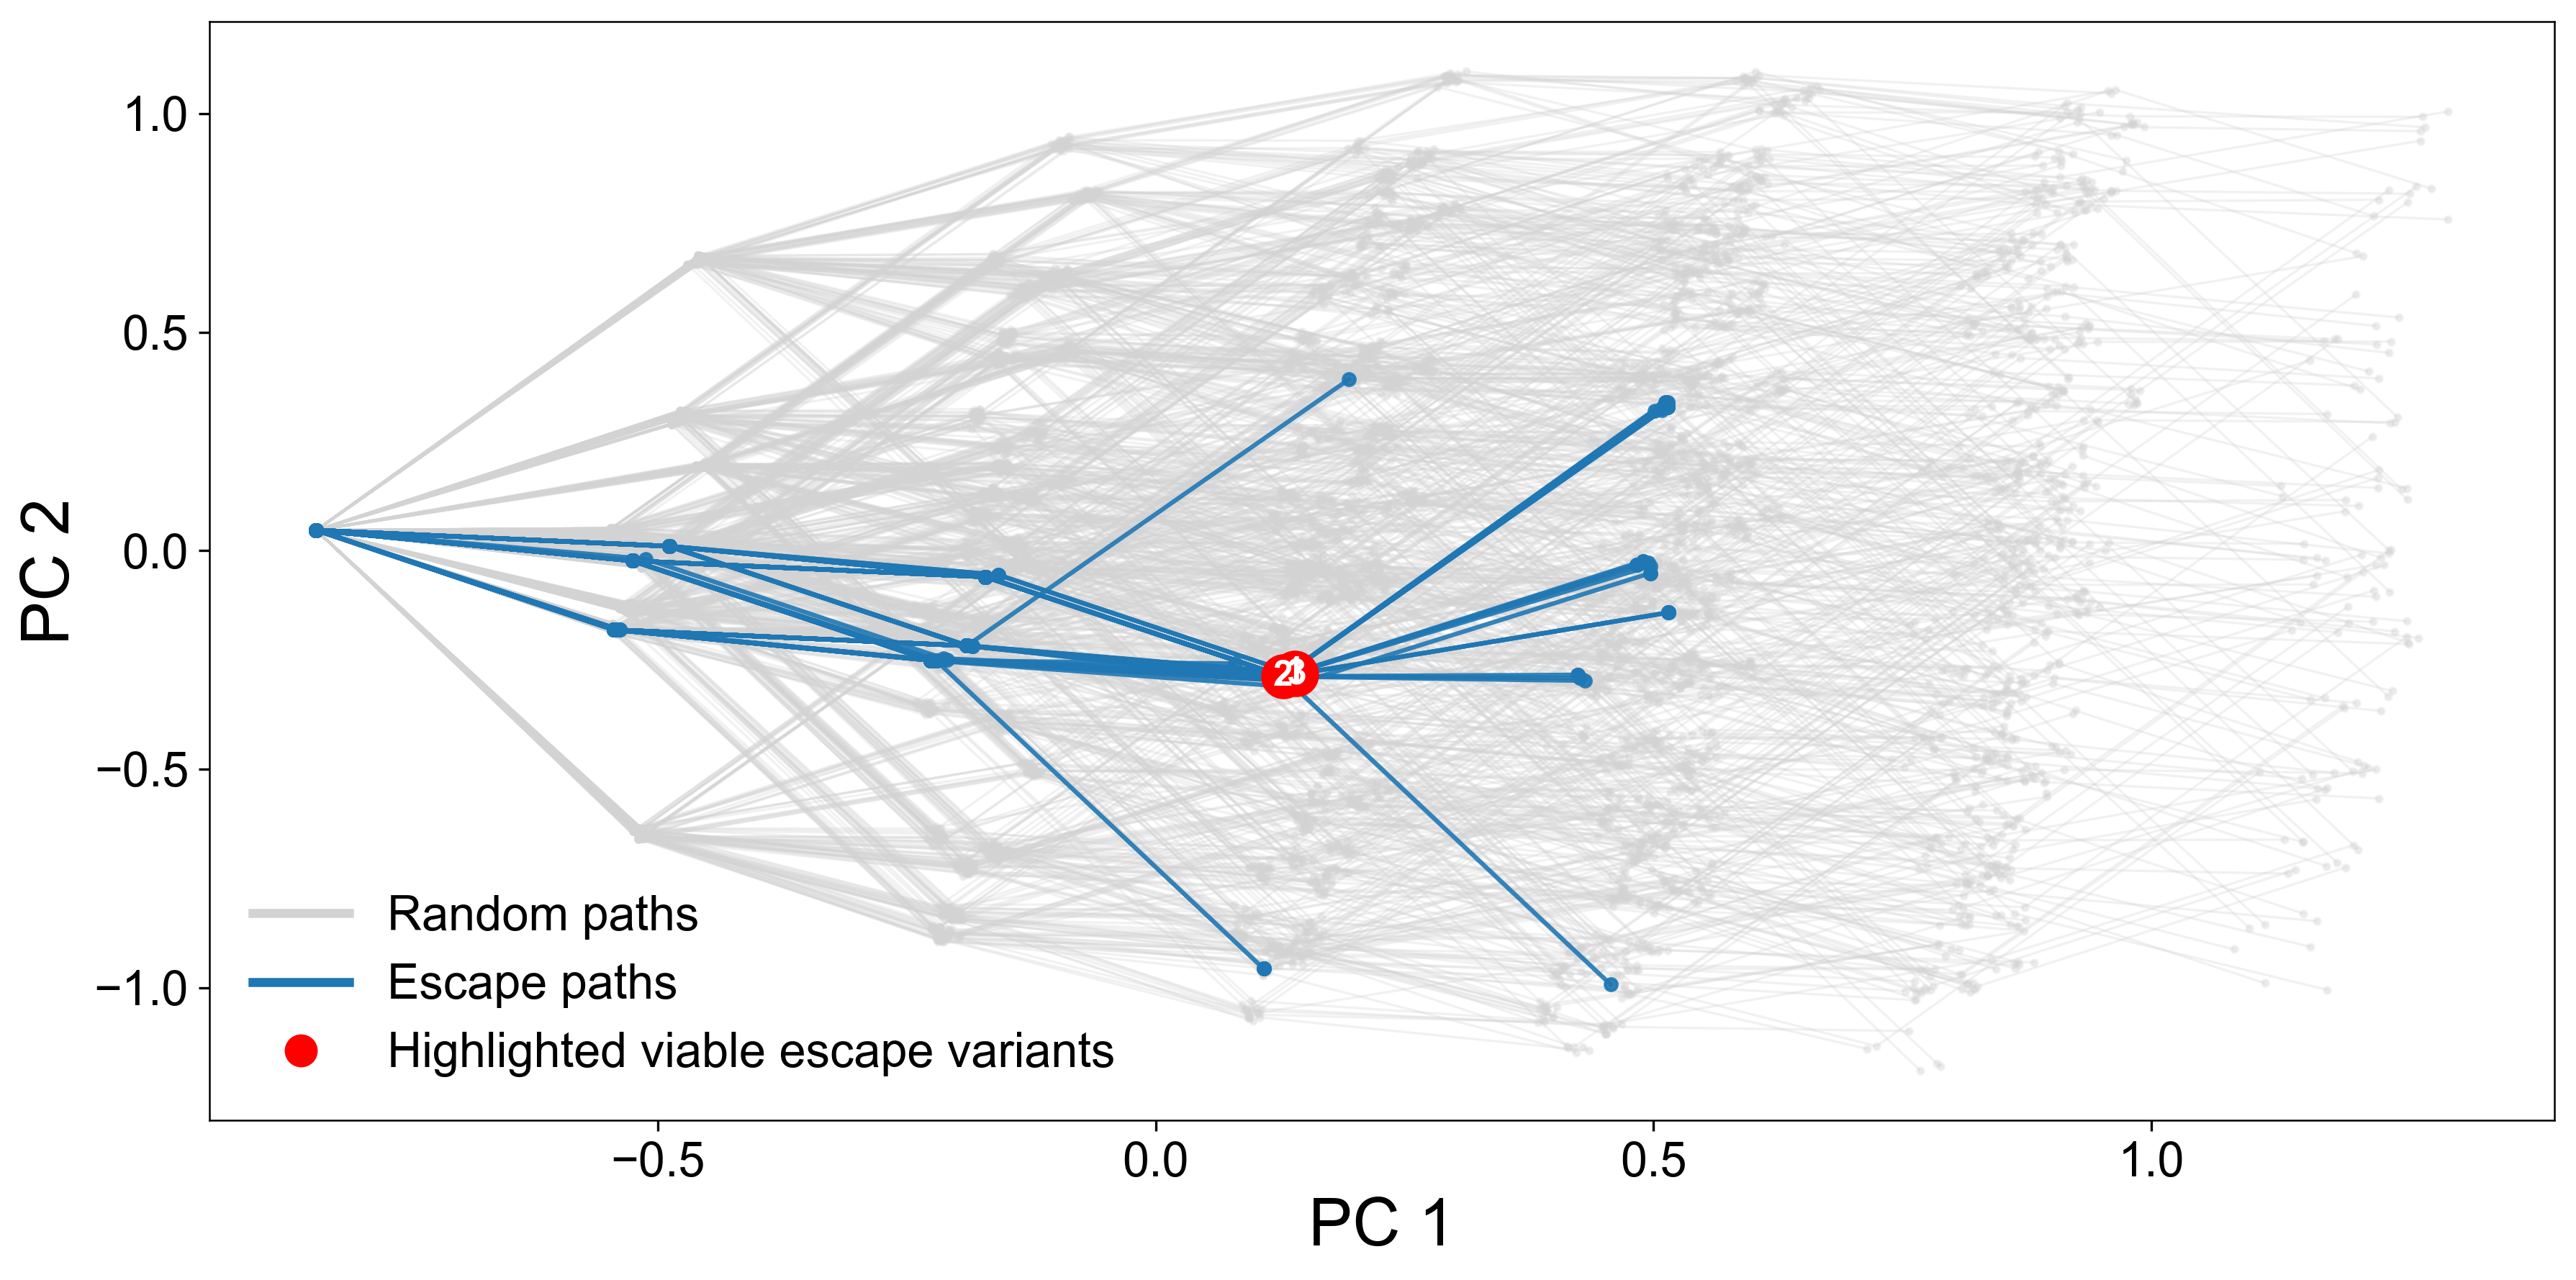

In [82]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-
"""
Visualise observed “escape” mutation paths against ×10 more neutral random paths.

Changes vs. original script
---------------------------
1. **No clustering** – K-means and colour palette removed.
2. **Highlight three random escape endpoints** – large red dots numbered 1-3.
3. **Second figure** – epitope cartoons for those three selected endpoints only.
---------------------------------------------------------------------------
You still need:
    • CODE_RBM, EPITOPE_SITES, sites_idx,
    • one_hot_encode_concat(), Proteins_utils.seq2num(),
    • consensus_epitope(), draw_epitope().
"""

# ─────────────────────────────── IMPORTS ────────────────────────────────
import os
import numpy as np
import matplotlib.pyplot as plt
from Bio import SeqIO
from matplotlib.lines import Line2D
from tqdm import tqdm

# ───────────────────────────── PARAMETERS ───────────────────────────────
k          = 3                 # **unused now** (kept for reference)
beta_w     = 3
paths_nb   = 100               # observed escape paths
rand_nb    = paths_nb * 10     # 10 × more random paths
steps      = 7                 # WT + 6 mutations
dir_in     = f"paths/indep_w_upper_T6_beta_w_{beta_w}/"
rng        = np.random.default_rng(0)

# ───────────────────── LOAD OBSERVED (ESCAPE) PATHS ─────────────────────
obs_seqs = []
for p in tqdm(range(paths_nb), desc="reading FASTA"):
    fasta = os.path.join(dir_in, f"output_{p}.fasta")
    obs_seqs.extend(SeqIO.parse(fasta, "fasta"))        # 7 seq per path

obs_num  = Proteins_utils.seq2num(obs_seqs)             # (paths_nb*7, L)
L        = obs_num.shape[1]
wt_num   = obs_num[0].copy()                            # assume first record is WT
obs_path_num = obs_num.reshape(paths_nb, steps, L)

# ─────────────────── BUILD RANDOM MUTATION PATHS ────────────────────────
rand_path_num = np.repeat(wt_num[None, None, :], rand_nb, axis=0)  # (R,1,L)
rand_path_num = np.tile(rand_path_num, (1, steps, 1))              # (R,7,L)

for r in range(rand_nb):
    seq = wt_num.copy()
    for t in range(1, steps):
        pos = rng.choice(sites_idx)           # random epitope position
        aa  = rng.integers(20)
        while aa == seq[pos]:
            aa = rng.integers(20)
        seq[pos] = aa
        rand_path_num[r, t] = seq.copy()

# ─────────────────────── ONE-HOT ENCODING ───────────────────────────────
obs_1hot  = np.array([one_hot_encode_concat(v) for v in obs_path_num.reshape(-1, L)])
rand_1hot = np.array([one_hot_encode_concat(v) for v in rand_path_num.reshape(-1, L)])

# ──────────────────────── PCA (covariance) ──────────────────────────────
def pca_fit_cov(X, n_comp=2):
    """PCA via eigendecomposition of the covariance matrix."""
    mu   = X.mean(axis=0, keepdims=True)
    Xc   = X - mu
    var  = Xc.var(axis=0)
    keep = var > 0                               # drop constant columns
    C    = (Xc[:, keep].T @ Xc[:, keep]) / (Xc.shape[0] - 1)
    _, vecs = np.linalg.eigh(C)                  # ascending eigen-values
    W_use = vecs[:, -n_comp:]                    # top PCs
    W     = np.zeros((X.shape[1], n_comp))
    W[keep] = W_use
    proj = Xc @ W
    return proj, W, mu.ravel()

# coords_rand_flat, eigvecs, mean_rand = pca_fit_cov(rand_1hot, n_comp=2)
# coords_obs_flat = (obs_1hot - mean_rand) @ eigvecs
def pca_fit_direct(X, n_comp=2):
    """
    PCA via SVD directly on centered one-hot matrix.
    Returns:
        coords  - projected coordinates (N, n_comp)
        W       - loadings (n_features, n_comp)
        mu      - mean vector (n_features,)
    """
    mu = X.mean(axis=0, keepdims=True)
    Xc = X - mu
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    coords = U[:, :n_comp] * S[:n_comp]  # projection of samples
    W = Vt[:n_comp].T                    # loadings
    return coords, W, mu.ravel()

# Fit PCA on random paths' one-hot features
coords_rand_flat, eigvecs, mean_rand = pca_fit_direct(rand_1hot, n_comp=2)

# Project observed paths into same space
coords_obs_flat = (obs_1hot - mean_rand) @ eigvecs


# optional stretch so the PCA scatter looks balanced
# x_ptp, y_ptp = coords_obs_flat[:, 0].ptp(), coords_obs_flat[:, 1].ptp()
# if x_ptp:
#     stretch = 0.5 * (y_ptp / x_ptp)
#     coords_rand_flat[:, 0] *= stretch
#     coords_obs_flat[:, 0]  *= stretch

coords_rand_path = coords_rand_flat.reshape(rand_nb,  steps, 2)
coords_obs_path  = coords_obs_flat.reshape(paths_nb, steps, 2)

# ───────────────────── PICK THREE RANDOM ESCAPE PATHS ───────────────────
# sel_idx = rng.choice(paths_nb, size=3, replace=False)   # e.g. [17, 42, 8]
from collections import Counter

# Get final sequences (step 6) from observed paths
final_obs_seqs = obs_path_num[:, -1, :]  # shape (paths_nb, L)

# Convert each sequence to a tuple so it can be hashed
final_seqs_tuples = [tuple(seq) for seq in final_obs_seqs]

# Count frequencies
counts = Counter(final_seqs_tuples)

# Get the 3 most common sequences
top3_seqs = [np.array(seq) for seq, _ in counts.most_common(3)]

# Find an index in obs_path_num matching each top3 sequence
sel_idx = []
for top_seq in top3_seqs:
    for i, seq in enumerate(final_obs_seqs):
        if np.array_equal(seq, top_seq):
            sel_idx.append(i)
            break

print("Selected path indices for top 3 most frequent escape endpoints:", sel_idx)


# ─────────────────────────── PLOT 1: PATHS ──────────────────────────────
plt.rcParams.update({
    'axes.titlesize': 26, 'axes.labelsize': 22,
    'xtick.labelsize': 16, 'ytick.labelsize': 16,
    'legend.fontsize': 16
})
fig, ax = plt.subplots(figsize=(12, 6))

# random paths in grey
for r in range(rand_nb):
    ax.plot(coords_rand_path[r, :, 0], coords_rand_path[r, :, 1],
            color='lightgrey', alpha=0.3, lw=0.8, marker='o', ms=2)

# escape paths in blue
for p in range(paths_nb):
    ax.plot(coords_obs_path[p, :, 0], coords_obs_path[p, :, 1],
            color='tab:blue', alpha=0.9, lw=1.5, marker='o', ms=4)

# highlight selected endpoints
for j, p in enumerate(sel_idx, start=1):
    x, y = coords_obs_path[p, -1]
    ax.plot(x, y, marker='o', ms=14, color='red', zorder=5)
    ax.text(x, y, f'{j}', va='center', ha='center',
            color='white', weight='bold', fontsize=12, zorder=6)

ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
# ax.set_title("Escape (blue) vs. random (grey) mutation paths")
ax.grid(False)

handles = [
    Line2D([0], [0], color='lightgrey', lw=3, label='Random paths'),
    Line2D([0], [0], color='tab:blue', lw=3, label='Escape paths'),
    Line2D([0], [0], marker='o', color='red', lw=0,
           markersize=10, label='Highlighted viable escape variants')
]
ax.legend(handles=handles, frameon=False, loc='best')

plt.tight_layout()
plt.show()


Mean distance to own consensus at step 1 — random: 1.0


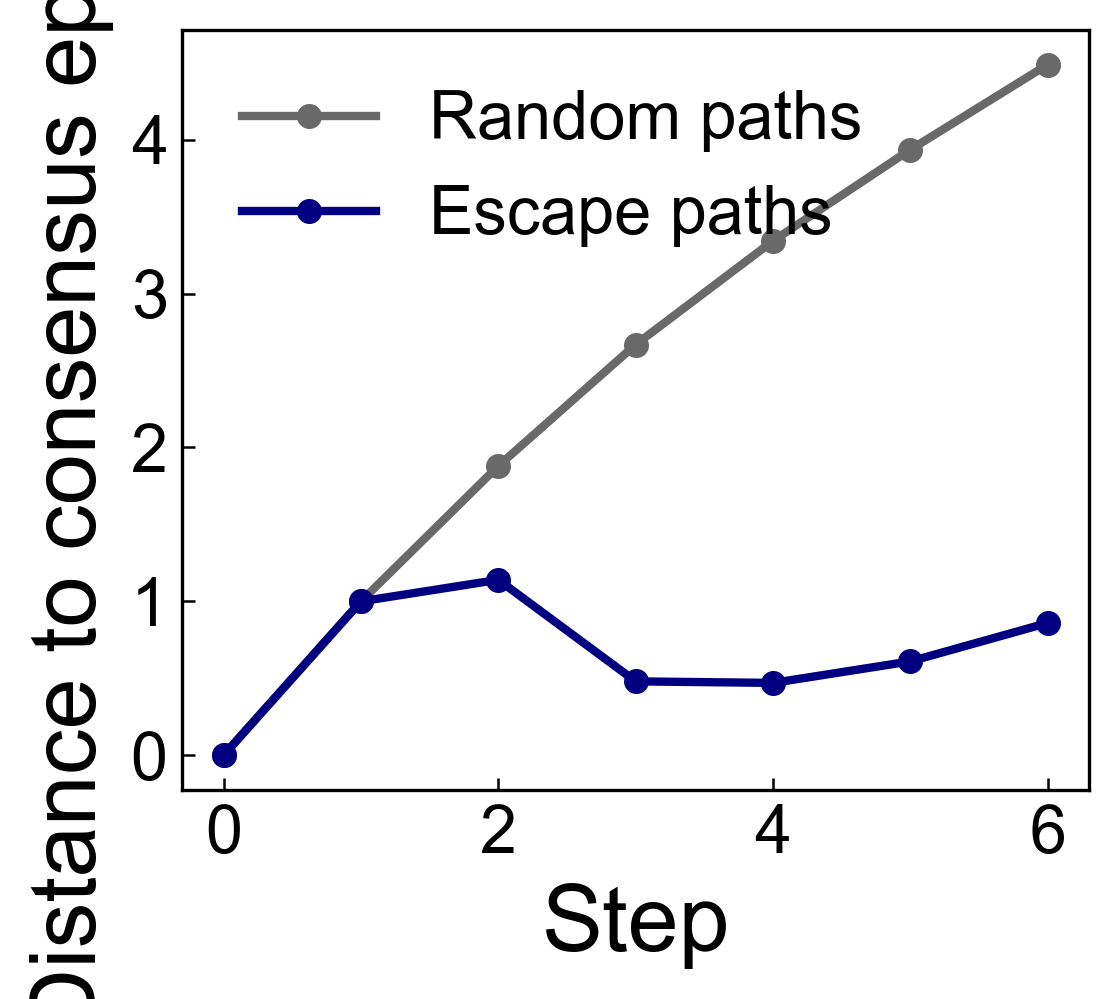

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.ticker as mticker

# Inputs expected:
#   rand_path_num: (N_rand, T, L) int-encoded sequences
#   obs_path_num : (N_obs,  T, L) int-encoded sequences
#   wt_num       : (L,)     int-encoded WT sequence
#   epitope_idx  : 1D array/list of 0-based epitope positions

epitope_idx = np.asarray(sites_idx, dtype=int)

def consensus_on_idx(seqs_at_step, idx, wt=None):
    """Consensus on idx: most frequent residue per site; break ties by preferring WT if given."""
    arr = np.asarray(seqs_at_step)
    L = arr.shape[1]
    cons = np.array(arr[0], copy=True)
    for j in idx:
        counts = Counter(arr[:, j].tolist())
        maxc = max(counts.values())
        candidates = [aa for aa, c in counts.items() if c == maxc]
        if wt is not None and wt[j] in candidates:
            cons[j] = wt[j]
        else:
            # deterministic pick among ties
            cons[j] = candidates[0]
    return cons

def consensus_per_step(paths_num, idx, wt=None):
    """List of per-step consensus sequences for one cohort."""
    N, T, L = paths_num.shape
    return [consensus_on_idx([paths_num[p, t] for p in range(N)], idx, wt=wt) for t in range(T)]

def distances_to_reference_consensus(paths_num, ref_cons_list, idx):
    """Per-path distances to given per-step consensus (Hamming on idx)."""
    N, T, L = paths_num.shape
    Y = np.zeros((N, T), dtype=float)
    for t in range(T):
        cons = ref_cons_list[t]
        # vectorized per-step Hamming on idx
        X = paths_num[:, t][:, idx]                # (N, |E|)
        c = np.tile(np.asarray(cons)[idx], (N, 1)) # (N, |E|)
        Y[:, t] = np.sum(X != c, axis=1)
    return Y

# --- Build each cohort’s OWN consensus (this is what you want) ---
ref_cons_rand = consensus_per_step(rand_path_num, epitope_idx, wt=wt_num)
ref_cons_obs  = consensus_per_step(obs_path_num,  epitope_idx, wt=wt_num)

# Distances to own consensus
Y_rand = distances_to_reference_consensus(rand_path_num, ref_cons_rand, epitope_idx)  # (N_rand, T)
Y_obs  = distances_to_reference_consensus(obs_path_num,  ref_cons_obs,  epitope_idx)  # (N_obs,  T)

# --- Quick sanity check: mean distance at step 1 should be ~1 for random paths with 1 mutation/seq ---
print("Mean distance to own consensus at step 1 — random:",
      Y_rand[:, 1].mean())

# --- Plot mean distance vs step ---
steps = np.arange(Y_obs.shape[1])
m_obs,  s_obs  = Y_obs.mean(0),  Y_obs.std(0, ddof=1)
m_rand, s_rand = Y_rand.mean(0), Y_rand.std(0, ddof=1)

fig, ax = plt.subplots(figsize=(3.8, 3.4))
ax.plot(steps, m_rand, '-o', color='dimgray', lw=2, ms=5, label='Random paths')
ax.plot(steps, m_obs,  '-o', color='navy',    lw=2, ms=5, label='Escape paths')

ax.set_xlabel("Step")
ax.set_ylabel("Distance to consensus epitope")
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))

for s in ax.spines.values():
    s.set_visible(True); s.set_color('black'); s.set_linewidth(0.8)
ax.tick_params(direction='in', length=3, width=0.6)
ax.legend(frameon=False, loc='best')
plt.tight_layout(); plt.show()


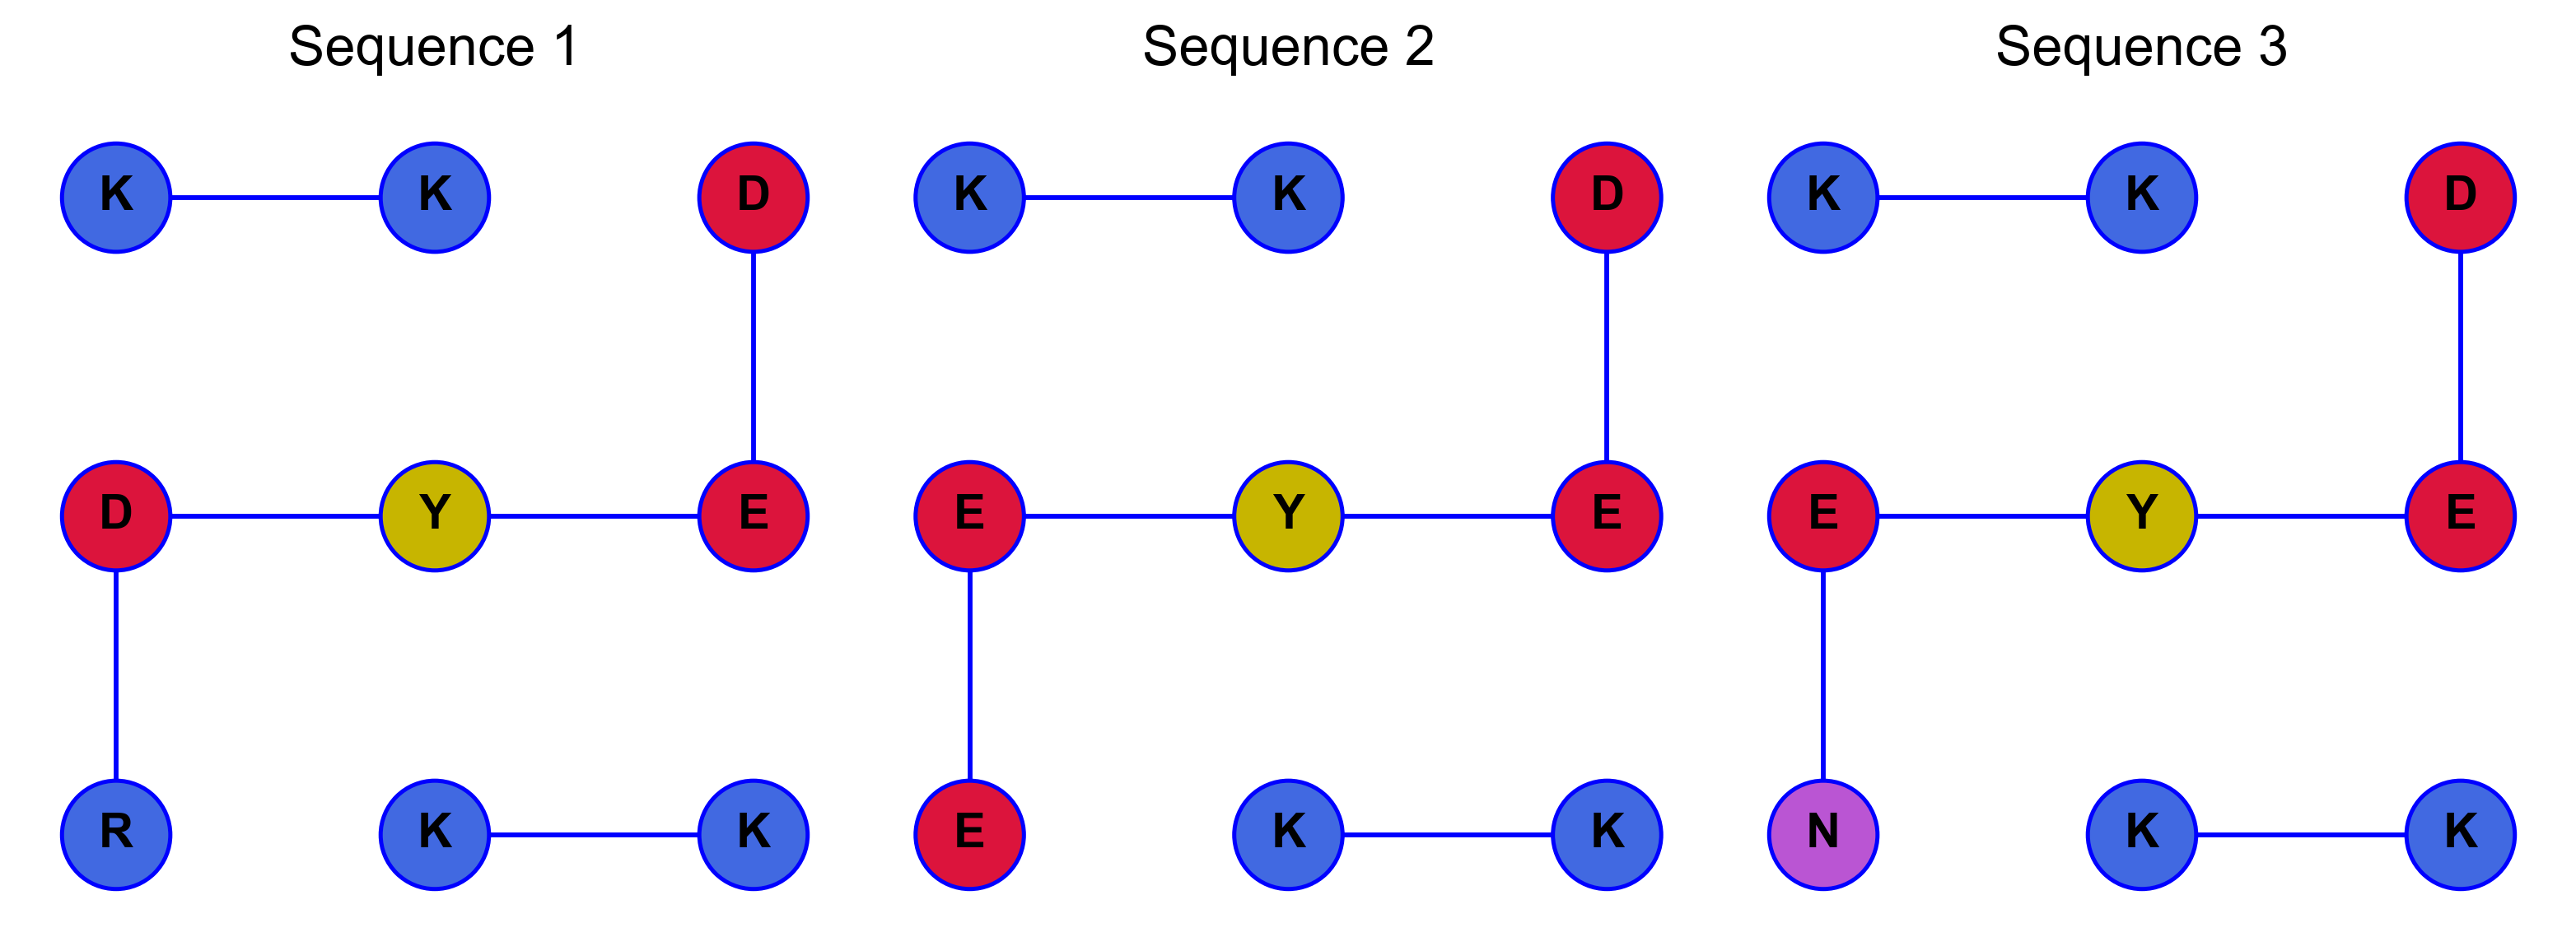

In [84]:

# ──────────────── PLOT 2: EPITOPE CARTOONS (3 ENDPOINTS) ───────────────
n_cols = len(sel_idx)                         # = 3
fig2, axes2 = plt.subplots(1, n_cols,
                           figsize=(3.5 * n_cols, 4),
                           squeeze=False)

for j, (ax_sub, p) in enumerate(zip(axes2[0], sel_idx), start=1):
    ax_sub.set_aspect("equal")
    ax_sub.axis("off")

    # numeric sequence of the final point
    last_seq_num = np.array([obs_path_num[p, -1, :]])     # shape (L,)
    res_map      = consensus_epitope(last_seq_num)  # user-defined

    draw_epitope(ax_sub,
                 centre=(0, 0),
                 residue_map=res_map,
                 edge_colour='blue',
                 scale=0.5, radius=0.17)

    ax_sub.set_title(f"Sequence {j}", fontsize=16, pad=12)

fig2.tight_layout()
plt.show()


# Look at seqs

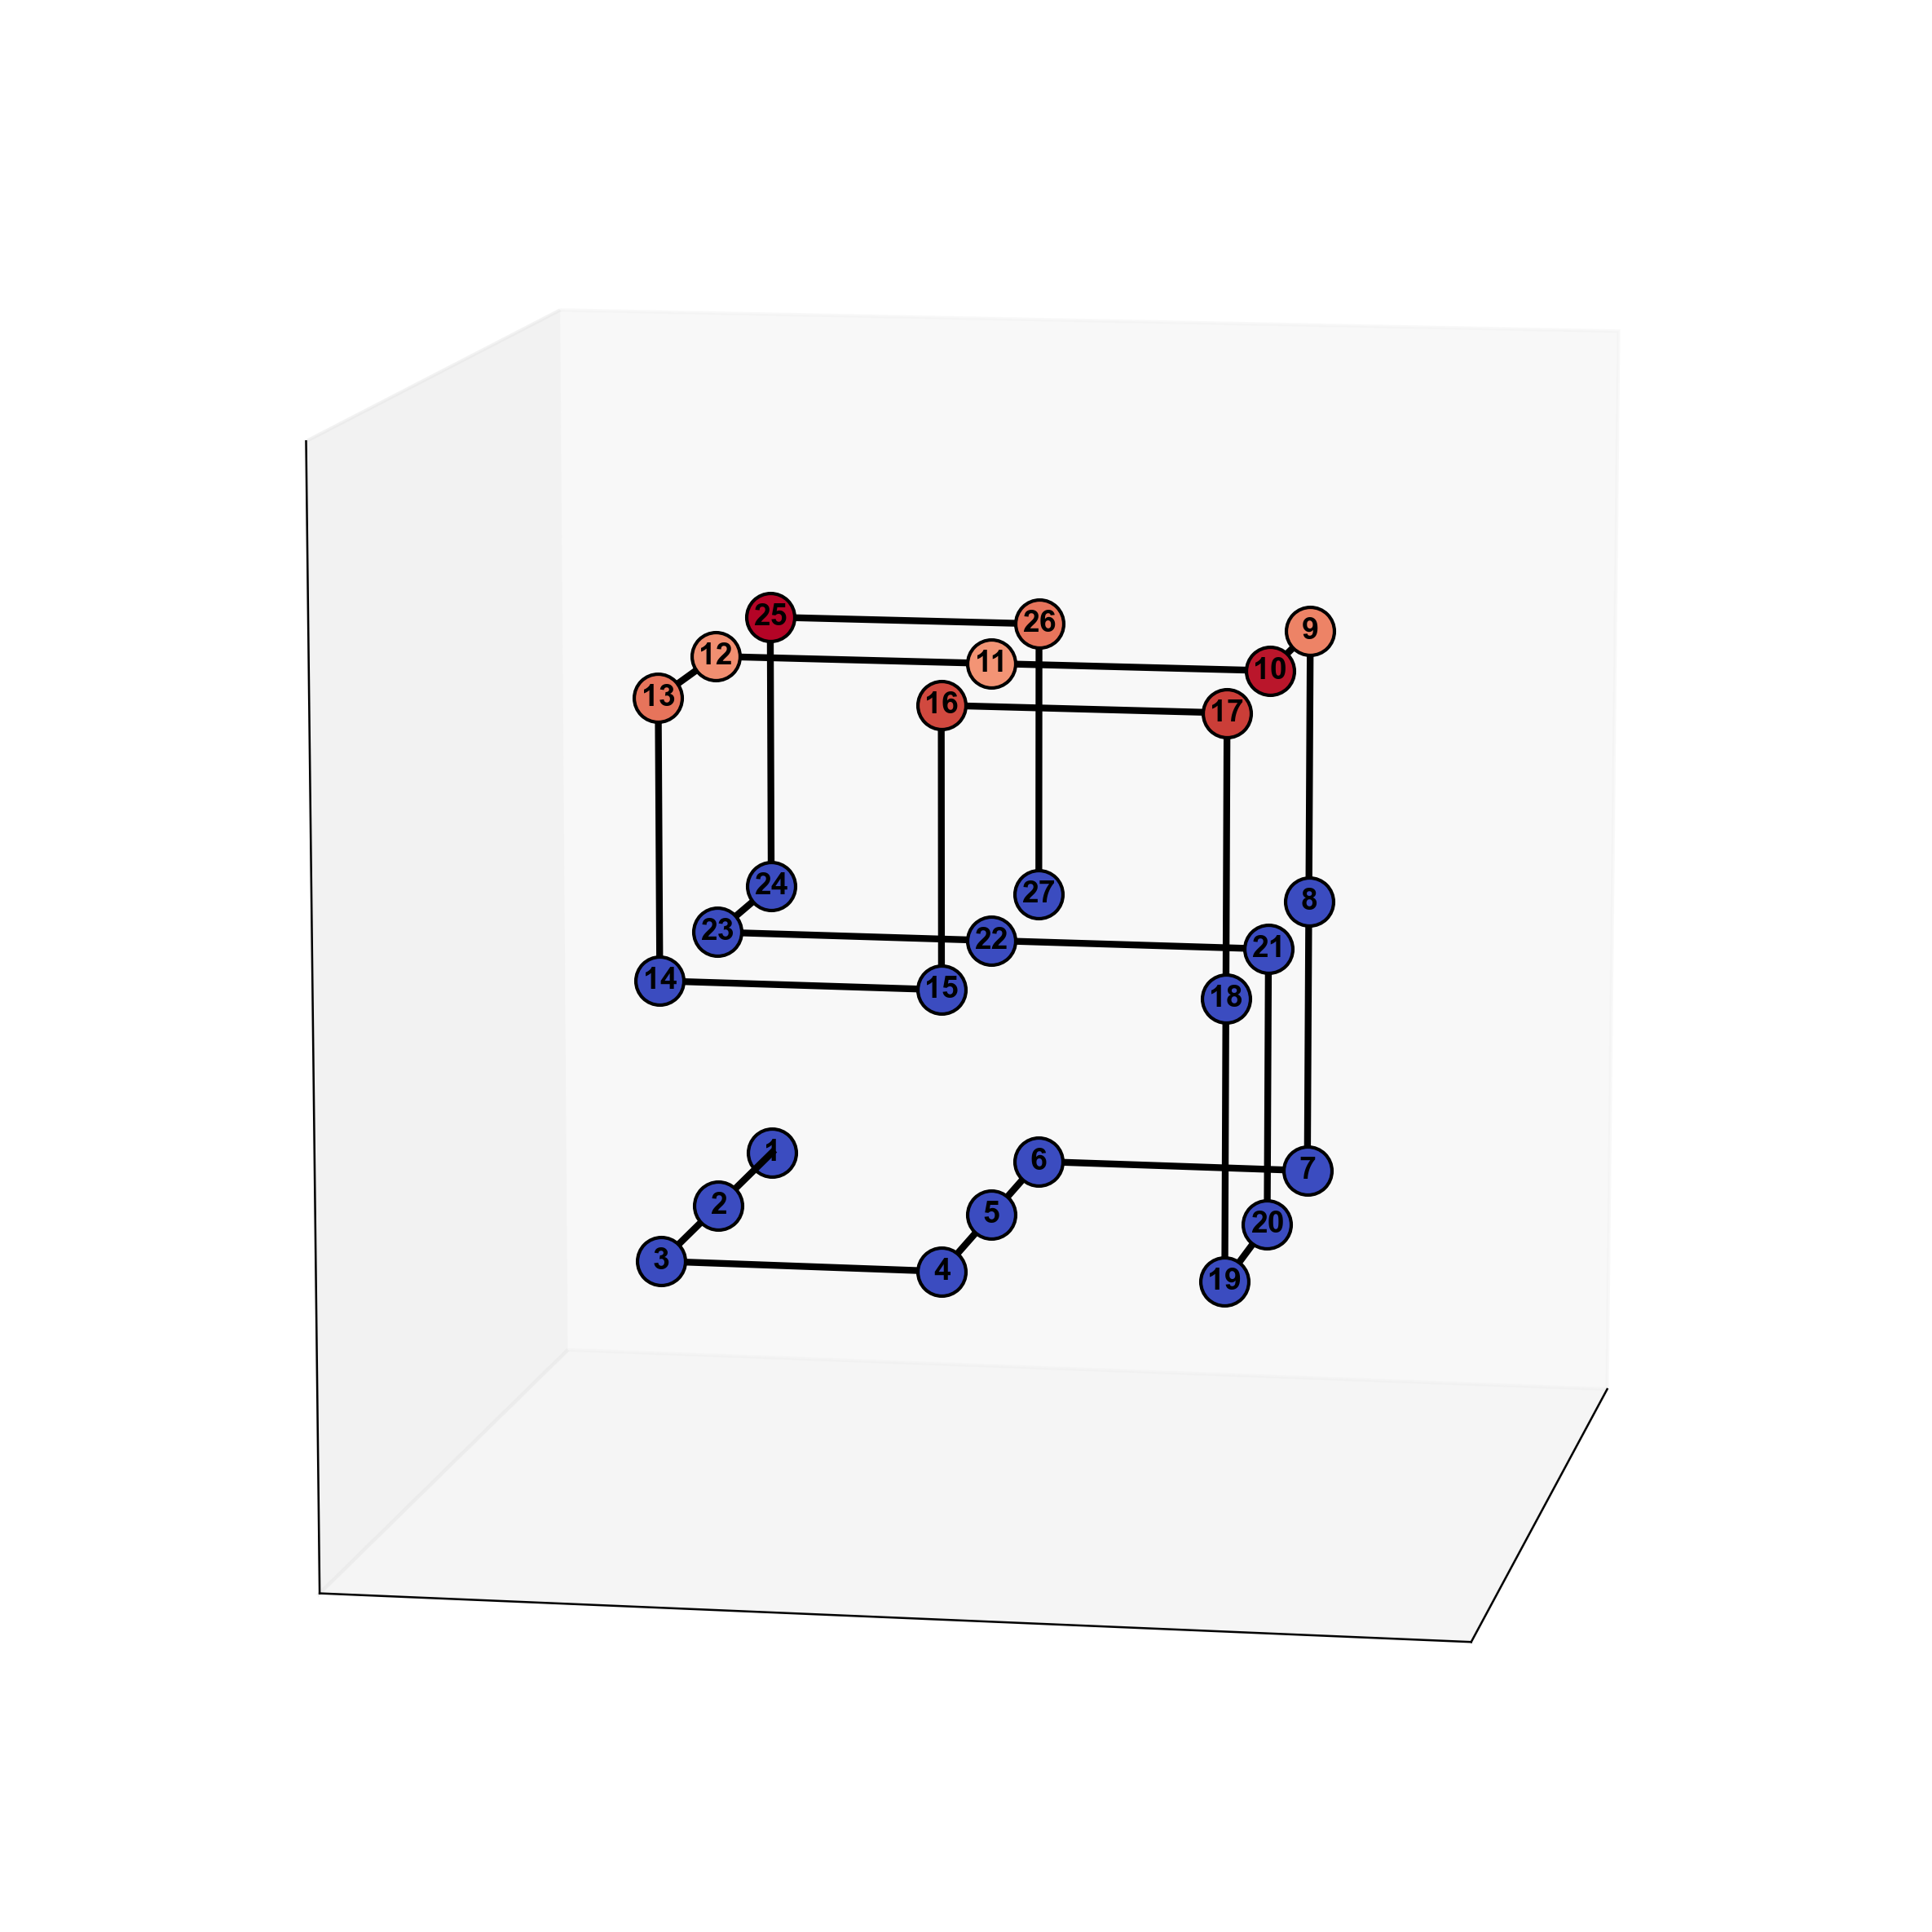

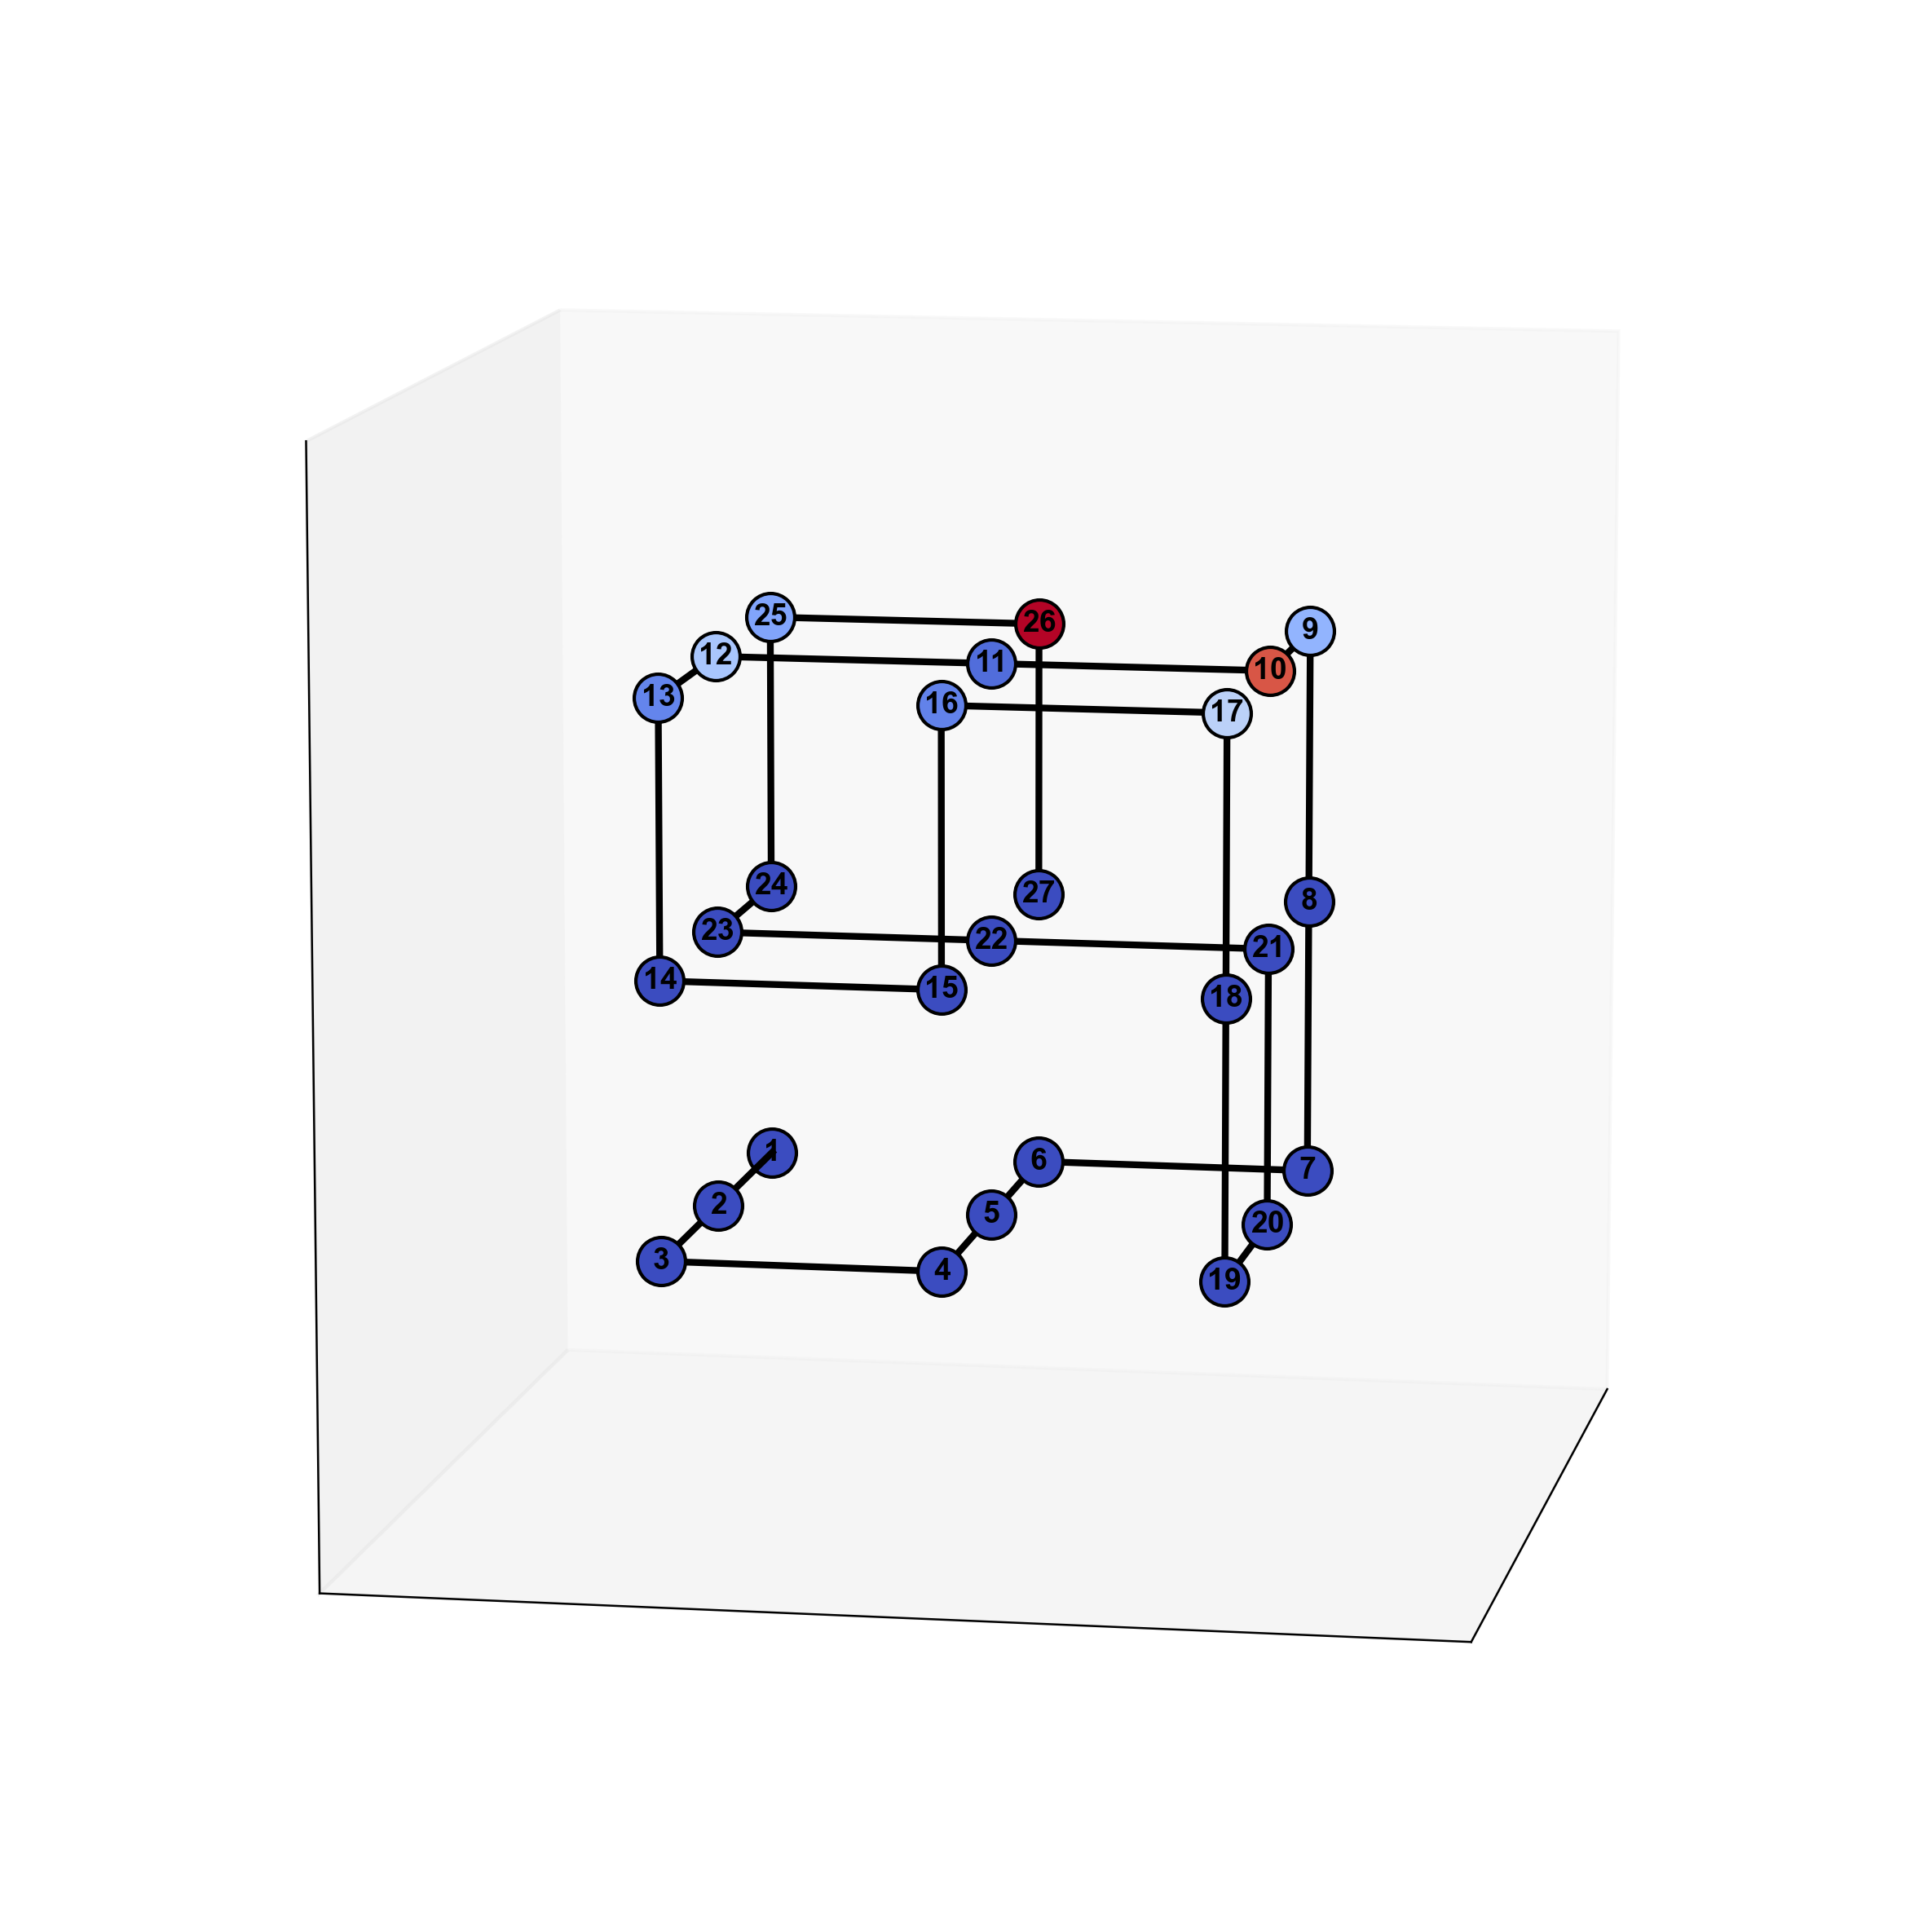

In [85]:
def per_site_pc1_weights(pc1, L, use_abs=True, sites_idx=None, normalize=True):
    """
    eigvecs: (20*L, n_comp) loadings from your PCA (columns = PCs)
    L:       protein length
    use_abs: sum |weights| per site (recommended); if False, uses signed sum
    sites_idx: iterable of epitope indices to keep; others set to 0 (optional)
    normalize: min-max to [0,1] for nicer colouring (optional)
    """
    site_x_aa = pc1.reshape(L, 20)            # (L, 20): site × amino-acid
    if use_abs:
        site_vals = np.abs(site_x_aa).sum(axis=1)
    else:
        site_vals = site_x_aa.sum(axis=1)

    if sites_idx is not None:
        mask = np.zeros(L)
        mask[np.asarray(sites_idx, dtype=int)] = 1.0
        site_vals = site_vals * mask

    if normalize:
        rng = site_vals.max() - site_vals.min()
        if rng > 0:
            site_vals = (site_vals - site_vals.min()) / rng

    return site_vals  # shape (L,)

# --- compute and plot ---
site_weights = per_site_pc1_weights(eigvecs[:, 0] , L, use_abs=True, sites_idx=None, normalize=True)
lattice.plot_lattice_protein(0, node_values=site_weights)
site_weights = per_site_pc1_weights(eigvecs[:, 1] , L, use_abs=True, sites_idx=None, normalize=True)
lattice.plot_lattice_protein(0, node_values=site_weights)



## WT

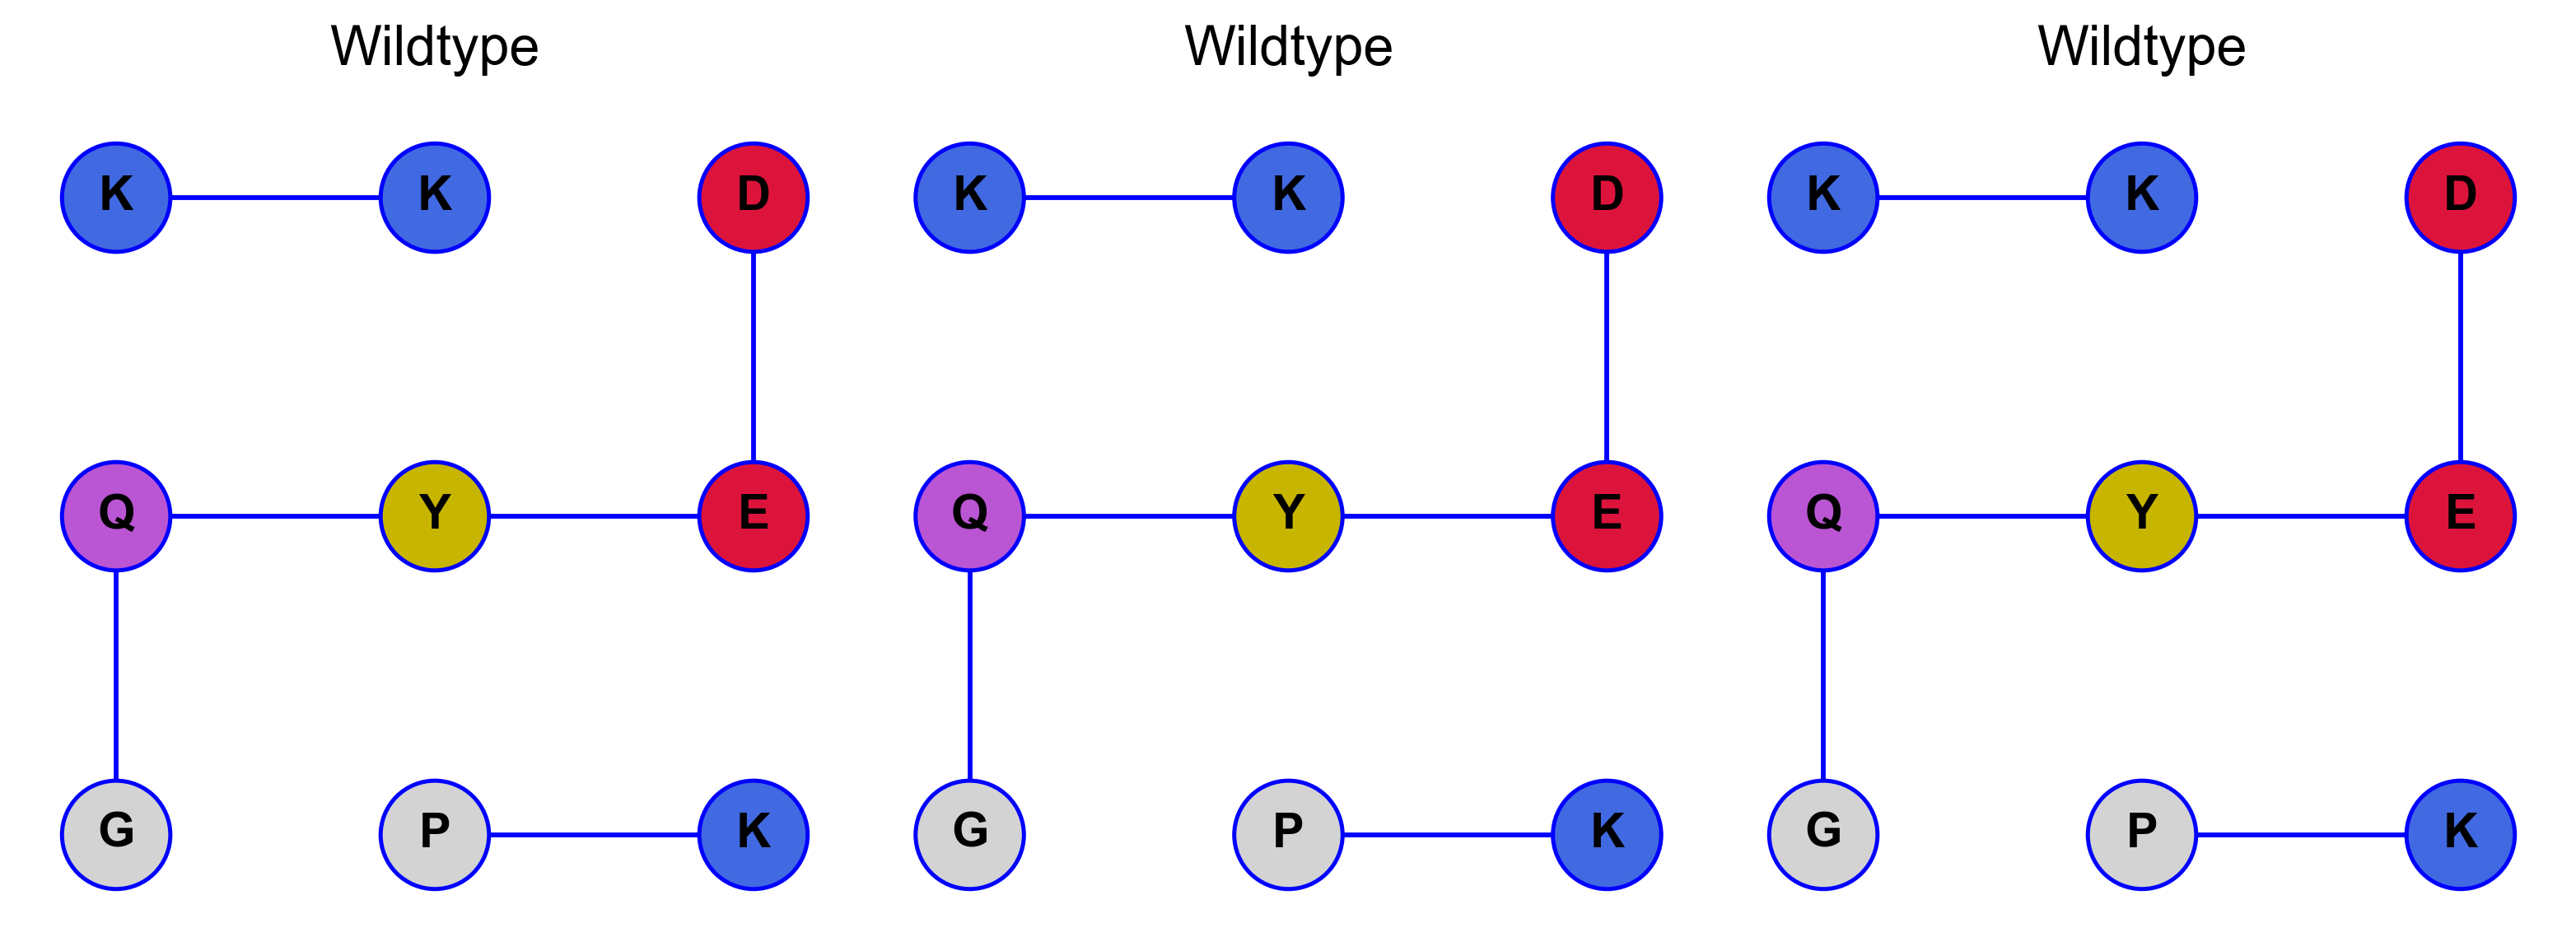

In [86]:
n_cols = len(sel_idx)                         # = 3
fig2, axes2 = plt.subplots(1, n_cols,
                           figsize=(3.5 * n_cols, 4),
                           squeeze=False)

for j, (ax_sub, p) in enumerate(zip(axes2[0], sel_idx), start=1):
    ax_sub.set_aspect("equal")
    ax_sub.axis("off")

    # numeric sequence of the final point
    last_seq_num = np.array([obs_path_num[p, 0, :]])     # shape (L,)
    res_map      = consensus_epitope(last_seq_num)  # user-defined

    draw_epitope(ax_sub,
                 centre=(0, 0),
                 residue_map=res_map,
                 edge_colour='blue',
                 scale=0.5, radius=0.17)

    ax_sub.set_title("Wildtype", fontsize=16, pad=12)

fig2.tight_layout()
plt.show()

# MSA fit

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# --- Load MSA and build one-hot as you already do ---
msa_seqs = Proteins_utils.load_FASTA('msa/output_msa_structure_0_beta_1000.fasta')
one_hot_msa = np.array([one_hot_encode_concat(v) for v in msa_seqs])

# Optional: set WT (defaults to first MSA sequence)
wt_seq = msa_seqs[0]



# Pnat

In [88]:
protein_lattice = lattice.ProteinLattice(structure_idx=0)
lattice_model = lattice.LatticeModel(protein_lattice)

    
class customed_lattice:
    def __init__(self, Lattice_model, w=None, beta_w=0, beta_lattice=1000):
        self.Lattice_model = Lattice_model
        self.w = w
        self.beta_w = beta_w
        self.beta_lattice = beta_lattice

    def __call__(self, v_string):
        v=Proteins_utils.seq2num(v_string)[0]

        v_transfo = lattice.string2seq(v_string)
        score = np.log(self.Lattice_model(v_transfo)) * self.beta_lattice
        if self.w is not None:
            score += self.beta_w * np.dot(one_hot_encode_concat(v), self.w)
        return score


In [89]:
import os
import numpy as np
import matplotlib.pyplot as plt
from Bio import SeqIO
from tqdm import tqdm
import matplotlib.ticker as mticker

# -------------------
# Config
# -------------------
paths_nb = 100
epitope_sites = np.array([9, 10, 11, 12, 13, 16, 17, 25, 26]) - 1  # 0-based
beta_lattice = 1000
beta_w = 3  # only this one
dir_in = f"paths/w_upper_T6_beta_w_{beta_w}/"

# Plot style (similar to consensus epitope plots)
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',
    'font.size': 12,
    'axes.labelsize': 13,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 300
})

# -------------------
# Collect paths
# -------------------
all_ll_customed = []  # will hold arrays per path: Pnat (as in your exp(...) transform)
all_ll_biased   = []  # epitope Hamming distance per path

for path_no in tqdm(range(paths_nb), desc=f"Reading β_w={beta_w}"):
    fasta_file = os.path.join(dir_in, f"output_{path_no}.fasta")
    if not os.path.exists(fasta_file):
        continue

    seqs = list(SeqIO.parse(fasta_file, "fasta"))
    if len(seqs) == 0:
        continue

    wt_seq = str(seqs[0].seq)
    ll_customed = []
    ll_biased   = []

    for record in seqs:
        seq = str(record.seq)
        # Epitope Hamming distance to WT
        epitope_overlap = sum(seq[j] != wt_seq[j] for j in epitope_sites)

        # Pnat (ground truth) via your custom model
        try:
            pnat = customed_lattice(Lattice_model=lattice_model, w=w,
                                    beta_w=beta_w, beta_lattice=beta_lattice)(seq)
        except Exception:
            continue

        # Your original transform:
        #   ll_c = (pnat - epitope_overlap * beta_w) / beta_lattice
        #   Pnat-like value = exp(ll_c)
        ll_c = (pnat - epitope_overlap * beta_w) / beta_lattice
        ll_customed.append(np.exp(ll_c))

        # Store epitope Hamming
        ll_biased.append(epitope_overlap)

    if len(ll_customed) == 0 or len(ll_biased) == 0:
        continue

    all_ll_customed.append(np.array(ll_customed))
    all_ll_biased.append(np.array(ll_biased))

# Early exit if nothing loaded
if len(all_ll_customed) == 0 or len(all_ll_biased) == 0:
    raise RuntimeError("No valid paths were loaded for β_w=3. Check input files.")

# Align by common minimum length across paths (if variable length)
min_T = min(arr.shape[0] for arr in all_ll_customed)
all_ll_customed = [arr[:min_T] for arr in all_ll_customed]
all_ll_biased   = [arr[:min_T] for arr in all_ll_biased]
steps = np.arange(min_T)



Reading β_w=3: 100%|██████████| 100/100 [01:54<00:00,  1.15s/it]


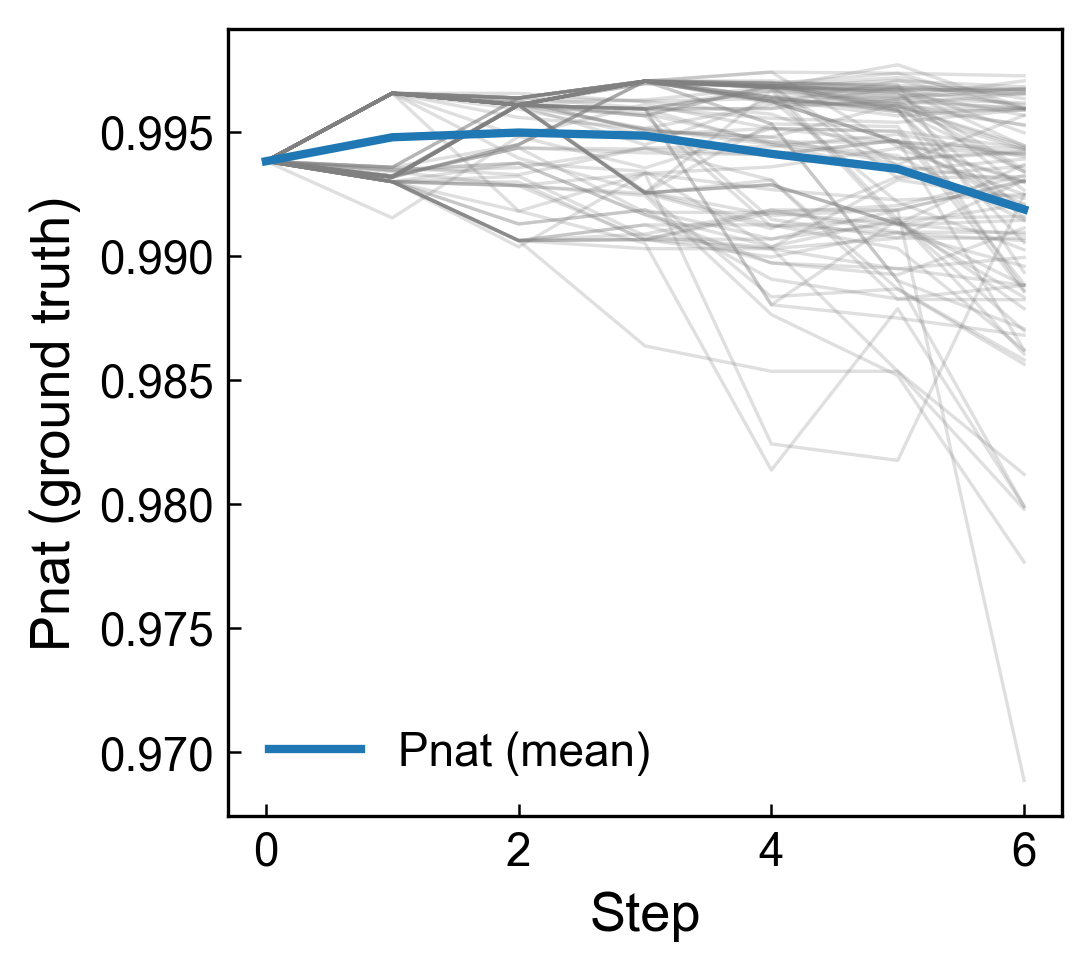

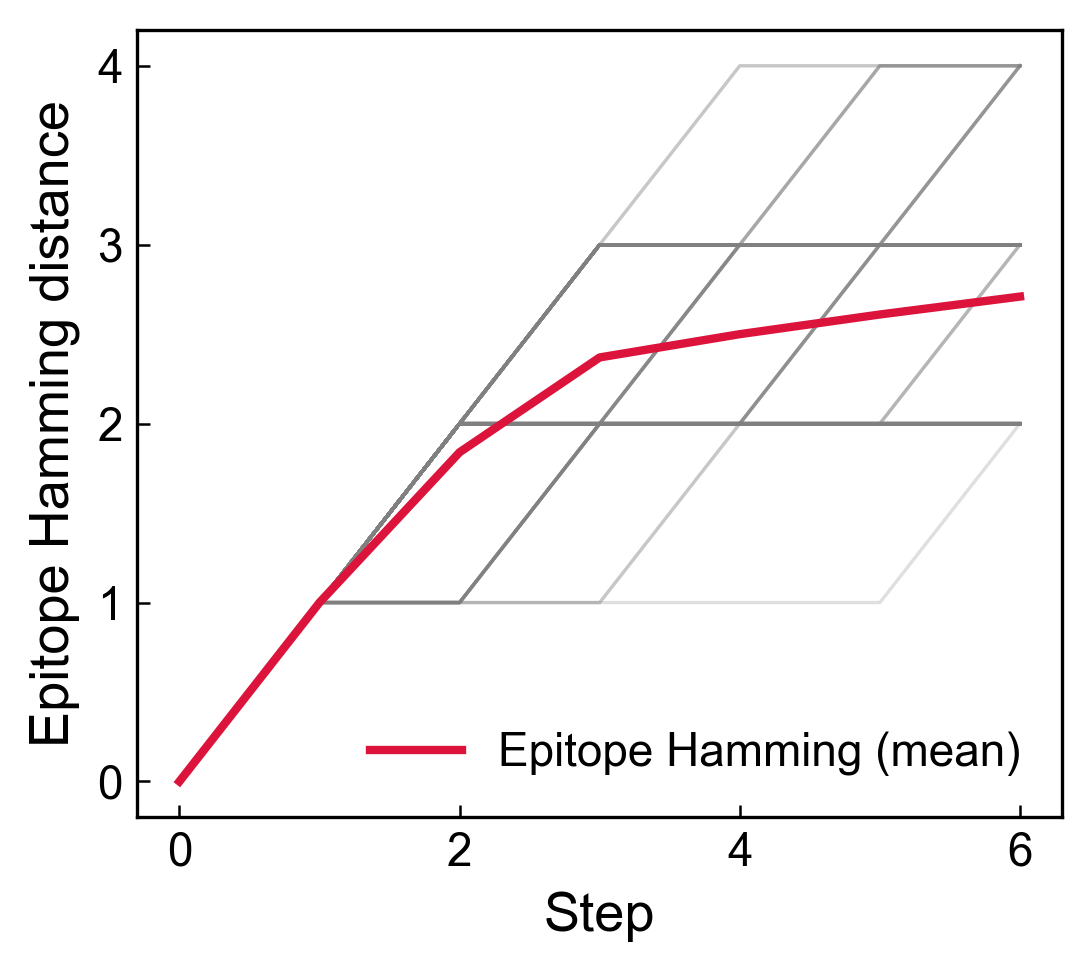

In [90]:
# -------------------
# Figure 1: Pnat (mean + faint individual paths)
# -------------------
fig, ax = plt.subplots(figsize=(3.8, 3.4))

for arr in all_ll_customed:
    ax.plot(steps, arr, color='gray', alpha=0.25, lw=0.8)

mean_customed = np.mean(np.vstack(all_ll_customed), axis=0)
ax.plot(steps, mean_customed, label="Pnat (mean)", lw=2, color='tab:blue')

ax.set_xlabel("Step")
ax.set_ylabel("Pnat (ground truth)")
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))

# Full black frame, inward ticks
for s in ax.spines.values():
    s.set_visible(True); s.set_color('black'); s.set_linewidth(0.8)
ax.tick_params(direction='in', length=3, width=0.6)

ax.legend(frameon=False, loc='best')
plt.tight_layout()
plt.show()

# -------------------
# Figure 2: Epitope Hamming distance (mean + faint individual paths)
# -------------------
fig, ax = plt.subplots(figsize=(3.8, 3.4))

for arr in all_ll_biased:
    ax.plot(steps, arr, color='gray', alpha=0.25, lw=0.8)

mean_biased = np.mean(np.vstack(all_ll_biased), axis=0)
ax.plot(steps, mean_biased, label="Epitope Hamming (mean)", lw=2, color='crimson')

ax.set_xlabel("Step")
ax.set_ylabel("Epitope Hamming distance")
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))

for s in ax.spines.values():
    s.set_visible(True); s.set_color('black'); s.set_linewidth(0.8)
ax.tick_params(direction='in', length=3, width=0.6)

ax.legend(frameon=False, loc='best')
plt.tight_layout()
plt.show()


## RBM paths assessed with ground truth

In [91]:
# import os
# import matplotlib.pyplot as plt
# import numpy as np
# from pathlib import Path
# from Bio import SeqIO
# from tqdm import tqdm
# stop()
# paths_nb = 100
# epitope_sites = np.array([9, 10, 11, 12, 13, 16, 17, 25, 26]) - 1
# beta_lattice=1000
# beta_array=[1,2,3]  # Different beta_w values to test
# # Create 2 rows: top for customed, bottom for biased
# fig, axs = plt.subplots(2, len(beta_array), figsize=(6 * len(beta_array), 12), dpi=150, sharex=False)
# axs = np.array(axs)  # Ensure it's a 2D array

# for i, beta_w in enumerate(beta_array):
#     customed_lattice_model= customed_lattice(Lattice_model=lattice_model, w=w, beta_w=beta_w, beta_lattice=beta_lattice)
#     dir = f"paths/w_upper_T6_beta_w_{beta_w}/"

#     all_ll_customed = []
#     all_ll_biased = []

#     for path_no in tqdm(range(paths_nb)):
#         fasta_file = os.path.join(dir, f"output_{path_no}.fasta")
#         seqs = list(SeqIO.parse(fasta_file, "fasta"))

#         # Skip if no sequences found        
#         if len(seqs) == 0:
#             continue

#         wt_seq = str(seqs[0].seq)
#         ll_customed = []
#         ll_biased = []

#         for record in seqs:
#             seq = str(record.seq)
#             epitope_overlap = sum(seq[j] != wt_seq[j] for j in epitope_sites)

#             # Parse pnat value from description
#             try:
#                 pnat = customed_lattice_model(seq)
#             except:
#                 continue

#             # Compute hamming distance on epitope sites
       
#             # Define values
#             ll_b = epitope_overlap
#             ll_c = (pnat - epitope_overlap*beta_w)/beta_lattice

#             ll_biased.append(ll_b)
#             ll_customed.append(ll_c)
        
#         #to array
#         ll_biased = np.array(ll_biased)
#         ll_customed = np.exp(np.array(ll_customed))



#         all_ll_biased.append(ll_biased)
#         all_ll_customed.append(ll_customed)


#         axs[0, i].plot(ll_customed, color='gray', alpha=0.3, lw=1)
#         axs[1, i].plot(ll_biased, color='gray', alpha=0.3, lw=1)

#     # Mean plots
#     mean_customed = np.mean(np.array(all_ll_customed), axis=0)
#     mean_biased = np.mean(np.array(all_ll_biased), axis=0)

#     axs[0, i].plot(mean_customed, label="Pnat", lw=2, color='blue')
#     axs[0, i].set_title(f"Beta_w = {beta_w}", fontsize=14)
#     axs[0, i].set_ylabel("Pnat ground truth")

#     axs[1, i].plot(mean_biased, label="epitope distance", lw=2, color='red')
#     axs[1, i].set_ylabel("Epitope hamming distance")
#     axs[0, i].set_xlabel("Step")
#     axs[1, i].set_xlabel("Step")


#     axs[0, i].legend()
#     axs[1, i].legend()

# plt.tight_layout()
# plt.show()


## Ground truth paths assessed with ground truth

In [92]:
# import os
# import matplotlib.pyplot as plt
# import numpy as np
# from pathlib import Path
# from Bio import SeqIO

# paths_nb = 100
# epitope_sites = np.array([9, 10, 11, 12, 13, 16, 17, 25, 26]) - 1
# beta_lattice=1000
# # Create 2 rows: top for customed, bottom for biased
# fig, axs = plt.subplots(2, len(beta_array), figsize=(6 * len(beta_array), 12), dpi=150)
# axs = np.array(axs)  # Ensure it's a 2D array
# beta_array=[1,2,3]
# for i, beta_w in enumerate(beta_array):
#     dir = f"paths/test_w_upper_T6_beta_w_{beta_w}/"

#     all_ll_customed = []
#     all_ll_biased = []

#     for path_no in range(paths_nb):
#         fasta_file = os.path.join(dir, f"output_{path_no}.fasta")
#         seqs = list(SeqIO.parse(fasta_file, "fasta"))
#         if len(seqs) == 0:
#             continue

#         wt_seq = str(seqs[0].seq)
#         ll_customed = []
#         ll_biased = []

#         for record in seqs:
#             seq = str(record.seq)
#             # Parse pnat value from description
#             try:
#                 pnat = float(record.description.split("pnat=")[-1])
#             except:
#                 continue

#             # Compute hamming distance on epitope sites
#             epitope_overlap = sum(seq[j] != wt_seq[j] for j in epitope_sites)

#             # Define values
#             ll_b = epitope_overlap
#             ll_c = (pnat - epitope_overlap*beta_w)/beta_lattice

#             ll_biased.append(ll_b)
#             ll_customed.append(ll_c)
        
#         #to array
#         ll_biased = np.array(ll_biased)
#         ll_customed = np.exp(np.array(ll_customed))



#         all_ll_biased.append(ll_biased)
#         all_ll_customed.append(ll_customed)


#         axs[0, i].plot(ll_customed, color='gray', alpha=0.3, lw=1)
#         axs[1, i].plot(ll_biased, color='gray', alpha=0.3, lw=1)

#     # Mean plots
#     mean_customed = np.mean(np.array(all_ll_customed), axis=0)
#     mean_biased = np.mean(np.array(all_ll_biased), axis=0)

#     axs[0, i].plot(mean_customed, label="mean", lw=2, color='blue')
#     axs[0, i].set_title(f"Beta_w = {beta_w}", fontsize=14)
#     axs[0, i].set_ylabel(r"$P_{nat}$")
#     axs[0, i].set_xlabel("Step")

#     axs[1, i].plot(mean_biased, label="mean", lw=2, color='red')
#     axs[1, i].set_xlabel("Step")
#     axs[1, i].set_ylabel("Epitope hamming distance")

#     axs[0, i].legend()
#     axs[1, i].legend()

# plt.tight_layout()
# plt.show()


# Sequence statistics at different steps

In [93]:
one_hot_wy=one_hot_encode_concat(PROTEIN_INIT)
indexes=np.where(one_hot_wy==1)[0]

In [94]:
def get_mcmc_proba(dir,step, paths_nb):
    last_seq_list = [] 
    for path_no in range(paths_nb):
        fasta_file = os.path.join(dir, f"output_{path_no}.fasta")
        if not os.path.exists(fasta_file):
            print('not found')
            continue
        sequences = Proteins_utils.load_FASTA(fasta_file, drop_duplicates=False)
        last_seq = sequences[step]  # Get the last sequence
        last_seq_list.append(last_seq)  # Append to the list

    last_seq_list=np.array(last_seq_list)
    position_weight_msa = utilities.average(last_seq_list,c=20) # Compute Position Weight Matrix (i.e. frequency of each amino acid at each site)
    proba_mcmc_flat=position_weight_msa.flatten()
    proba_mcmc_flat=np.delete(proba_mcmc_flat, indexes)
    #reshape to (27*19)
    proba_mcmc_flat=proba_mcmc_flat.reshape(27,19)
    #sum over axis 0
    proba_mcmc_flat=np.sum(proba_mcmc_flat, axis=1)
    # proba_mcmc_flat=proba_mcmc_flat.max(axis=1)
    return proba_mcmc_flat

C:\Users\maria\AppData\Local\Temp\ipykernel_17200\971925859.py:34: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_rbm, _ = pearsonr(proba_rbm, proba_latt)
C:\Users\maria\AppData\Local\Temp\ipykernel_17200\971925859.py:35: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_indep, _ = pearsonr(proba_indep, proba_latt)


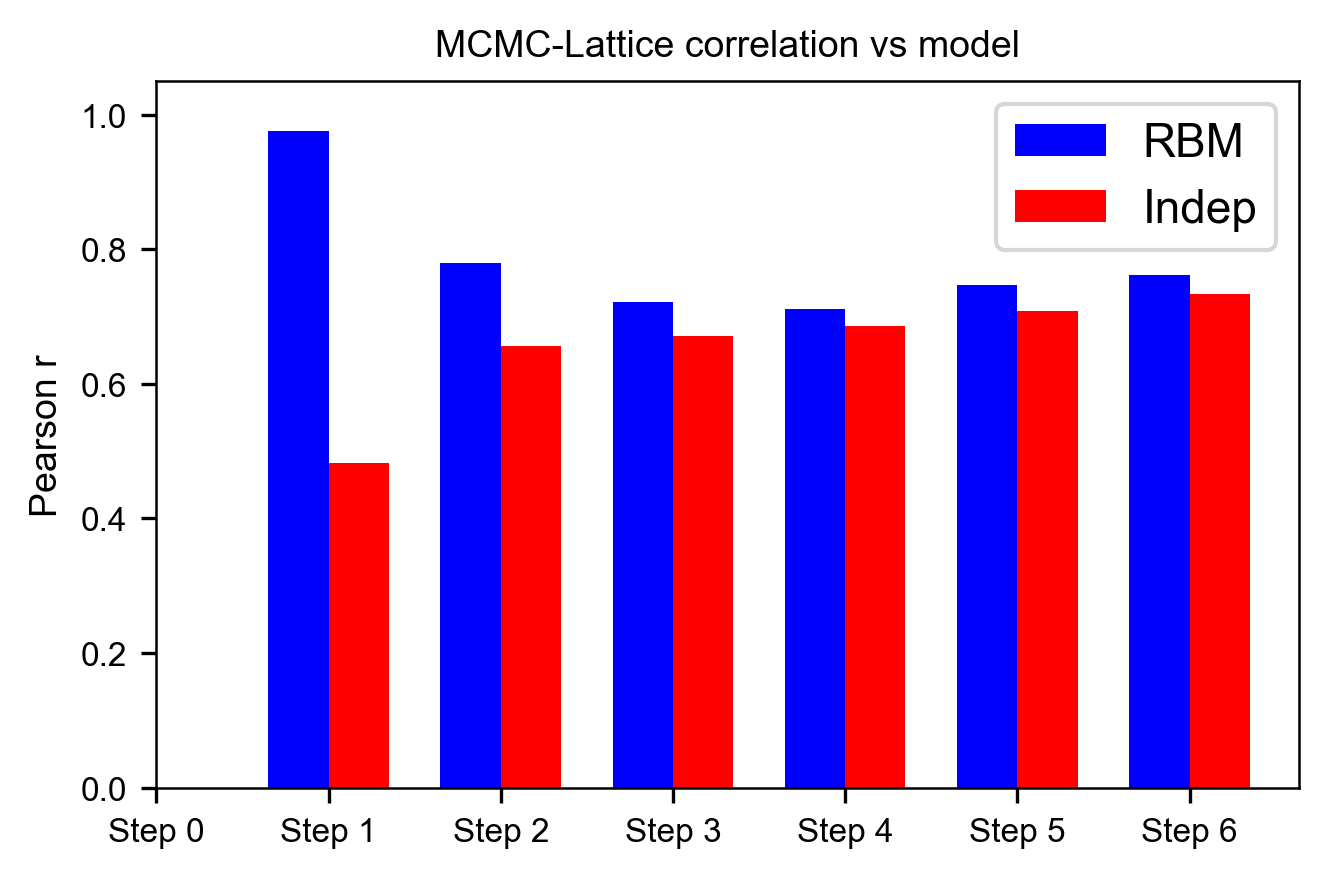

In [96]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from scipy.stats import pearsonr

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.6,
    "lines.linewidth": 1.0,
    "figure.dpi": 300,
})

# ── Parameters ─────────────────────────────────────────────
steps = [0, 1, 2, 3, 4, 5,6]  # Time steps to analyze
dir_latt   = "paths/test_w_upper_T6_beta_w_1/"
dir_indep = "paths/indep_w_upper_T6_beta_w_1/"
dir_rbm  = "paths/w_upper_T6_beta_w_1/"

# ── Compute Pearson correlations ───────────────────────────
pearsons_rbm = []
pearsons_indep = []

for step in steps:
    proba_rbm   = get_mcmc_proba(dir_rbm, step, 100)
    proba_indep = get_mcmc_proba(dir_indep, step, 100)
    proba_latt  = get_mcmc_proba(dir_latt, step, 100)

    r_rbm, _ = pearsonr(proba_rbm, proba_latt)
    r_indep, _ = pearsonr(proba_indep, proba_latt)

    pearsons_rbm.append(r_rbm)
    pearsons_indep.append(r_indep)

# ── Bar Plot ───────────────────────────────────────────────
x = np.arange(len(steps))
width = 0.35

fig, ax = plt.subplots(figsize=(4.5, 3))
ax.bar(x - width/2, pearsons_rbm, width, label='RBM', color='blue')
ax.bar(x + width/2, pearsons_indep, width, label='Indep', color='red')

ax.set_xticks(x)
ax.set_xticklabels([f"Step {s}" for s in steps])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Pearson r")
ax.set_title("MCMC-Lattice correlation vs model")
ax.legend(frameon=True, loc='best')

plt.tight_layout()
plt.show()
